In [1]:
import uproot
import pandas as pd
import numpy as np
import awkward as ak
import os
import json
import ROOT

In [2]:
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 100
import matplotlib.gridspec as gridspec
import matplotlib.patches as patches
import matplotlib.lines as lines
from matplotlib.collections import PatchCollection
plt.rcParams.update({'font.size': 15})

In [3]:
basedir = os.path.join(os.environ.get('ttH_yy_DIR'), 'final')
outdir = os.path.join(os.environ.get('ttH_yy_DIR'), 'plots')
color_sequence = ["#3f90da","#ffa90e","#bd1f01","#94a4a2","#832db6","#a96b59","#e76300","#b9ac70","#717581","#92dadd"]
process = {
    'ttHyy' : { 'sample_list' : ['mgp8_pp_tth01j_5f_haa'], 
               'label' : r'$ttH \rightarrow \gamma\gamma$',
               'color' : color_sequence[0]},
    'ttyy' : { 'sample_list' : ['mgp8_pp_ttaa_semilep_5f_100TeV'], 
               'label' : '$tt\gamma\gamma$',
               'color' : color_sequence[1]}
}

selection = {
    'nocuts' : "All events"
}

process_infos = "/eos/experiment/fcc/hh/utils/FCCDicts/FCChh_procDict_fcc_v06_II.json"

lumi = 3e7 # 3 * 10^7 pb-1 = 3 ab-1

In [4]:
def error_boxes (ax,x,y,x_err,y_err,fc='lightgrey',ec='None',alpha=0.5, hatch=None):

    # Create list for all the error patches
    errorboxes = []

    # Loop over data points; create box from errors at each point
    for xc,yc,xe,ye in zip(x,y,x_err.T,y_err.T):
        rect = patches.Rectangle((xc-xe,yc-ye),2*xe,2*ye)
        errorboxes.append(rect)

    # Create patch collection with specified colour/alpha
    pc = PatchCollection(errorboxes,facecolor=fc,alpha=alpha,edgecolor=ec, hatch=hatch)

    # Add collection to axes
    ax.add_collection(pc)

In [5]:
with open(process_infos, 'r') as f :
    process_dict = json.load(f)

In [27]:
rdf = {}
sow = {}

In [28]:
for p in process.keys() :
    rdf[p] = {}
    for s in selection.keys() :
        rdf[p][s] = {}
        sow[p] = {}
        for sample in process[p]['sample_list'] : 
            inputfile = os.path.join(basedir, sample+"_"+s+".root")
            # get sum of weights
            f = ROOT.TFile.Open(inputfile)
            sow[p][sample] = f.Get("SumOfWeights").GetVal()
            f.Close()
            # get sample
            rdf[p][s][sample] = ROOT.RDataFrame("events", inputfile)
            weight = "weight/{sow}*{xs}*{k}*{eff}".format(
                sow=sow[p][sample],
                xs = process_dict[sample]['crossSection'],
                k = process_dict[sample]['kfactor'],
                eff = process_dict[sample]['matchingEfficiency']
            )
            rdf[p][s][sample] = rdf[p][s][sample].Redefine("weight", weight)

In [29]:
for p in process.keys() :
    for s in selection.keys() :
        for sample in process[p]['sample_list'] : 
            rdf[p][s][sample] = rdf[p][s][sample].Define("pT_jet5", "n_jets >= 5 ? pT_jets[4] : -999.")
            rdf[p][s][sample] = rdf[p][s][sample].Define("pT_jet6", "n_jets >= 6 ? pT_jets[5] : -999.")

In [30]:
histo = {}

In [31]:
for p in process.keys() :
    histo[p] = {}
    for s in selection.keys() :
        histo[p][s] = {}
        model = ROOT.RDF.TH1DModel("", "", 50, 0., 200.) 
        histo[p][s] = rdf[p][s][process[p]['sample_list'][0]].Histo1D(model, "pT_jet5", "weight")
        for sample in process[p]['sample_list'][1:] :
            temp = rdf[p][s][sample].Histo1D(model, "pT_jet5", "weight")
            histo[p][s].Add(temp)

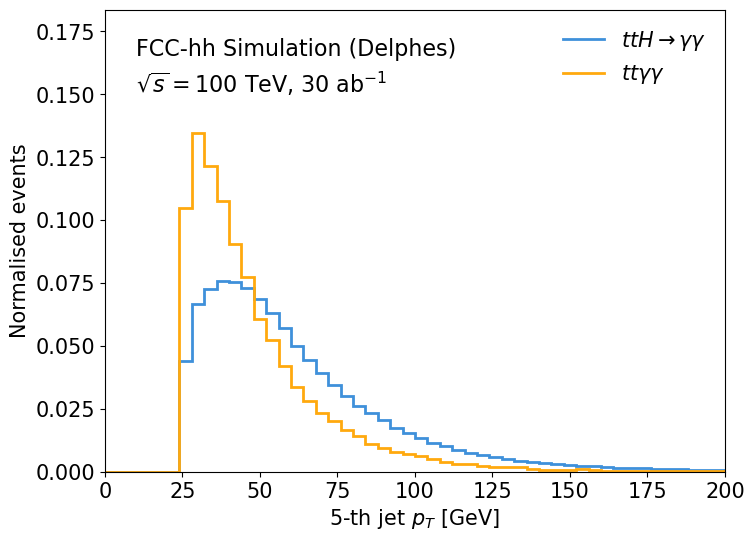

In [32]:
fig, ax = plt.subplots(
    nrows=1,
    ncols=1,
    figsize=(8,6)
)

sel_key = list(selection.keys())[0]
sel_label = list(selection.keys())[0]

for p in process.keys() :
    nbins = histo[p][sel_key].GetXaxis().GetNbins()
    bin_edges  = [histo[p][sel_key].GetXaxis().GetBinLowEdge(i+1) for i in range(0, nbins+1)]
    bin_values = [histo[p][sel_key].GetBinContent(i+1) for i in range(0, nbins)]
    bin_errors = [histo[p][sel_key].GetBinError(i+1) for i in range(0, nbins)]
    norm = np.sum(np.array(bin_values))
    ax.stairs(bin_values/norm, bin_edges, fill=False, linestyle='-', linewidth=2, color=process[p]["color"], label=process[p]["label"])

#ax.text(0.05, 0.90, r"$ttH \rightarrow \gamma\gamma$", transform=ax.transAxes, fontsize=18)
ax.text(0.05, 0.90, r"FCC-hh Simulation (Delphes)", transform=ax.transAxes, fontsize=16)

ax.text(0.05, 0.82, r"$\sqrt{s}=100$ TeV, 30 ab$^{-1}$", transform=ax.transAxes, fontsize=16)

ax.legend(loc='upper right', frameon=False, fontsize=15)

ax.set_xlabel(r'5-th jet $p_{T}$ [GeV]')    
ax.set_ylabel(r'Normalised events')

ax.set_xlim(bin_edges[0], bin_edges[-1])
ymin,ymax = ax.get_ylim() 
ax.set_ylim(ymin, ymax+np.abs((ymax-ymin))*0.3)

plotname = os.path.join(outdir, "pT_jet5_ttH_yy_analysis.pdf")
plt.savefig(plotname, bbox_inches='tight')
plotname = os.path.join(outdir, "pT_jet5_ttH_yy_analysis.png")
plt.savefig(plotname, bbox_inches='tight')
plt.show()

In [33]:
histo = {}

In [34]:
for p in process.keys() :
    histo[p] = {}
    for s in selection.keys() :
        histo[p][s] = {}
        model = ROOT.RDF.TH1DModel("", "", 50, 0., 200.) 
        histo[p][s] = rdf[p][s][process[p]['sample_list'][0]].Histo1D(model, "pT_jet6", "weight")
        for sample in process[p]['sample_list'][1:] :
            temp = rdf[p][s][sample].Histo1D(model, "pT_jet6", "weight")
            histo[p][s].Add(temp)

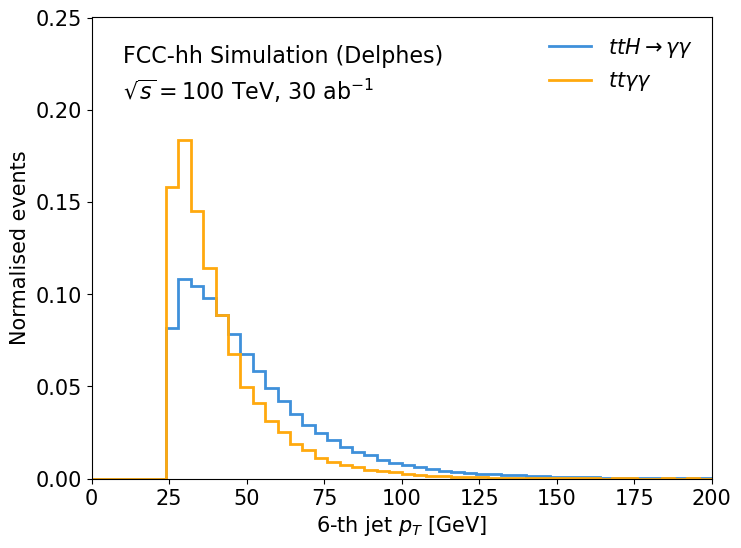

In [35]:
fig, ax = plt.subplots(
    nrows=1,
    ncols=1,
    figsize=(8,6)
)

sel_key = list(selection.keys())[0]
sel_label = list(selection.keys())[0]

for p in process.keys() :
    nbins = histo[p][sel_key].GetXaxis().GetNbins()
    bin_edges  = [histo[p][sel_key].GetXaxis().GetBinLowEdge(i+1) for i in range(0, nbins+1)]
    bin_values = [histo[p][sel_key].GetBinContent(i+1) for i in range(0, nbins)]
    bin_errors = [histo[p][sel_key].GetBinError(i+1) for i in range(0, nbins)]
    norm = np.sum(np.array(bin_values))
    ax.stairs(bin_values/norm, bin_edges, fill=False, linestyle='-', linewidth=2, color=process[p]["color"], label=process[p]["label"])

#ax.text(0.05, 0.90, r"$ttH \rightarrow \gamma\gamma$", transform=ax.transAxes, fontsize=18)
ax.text(0.05, 0.90, r"FCC-hh Simulation (Delphes)", transform=ax.transAxes, fontsize=16)

ax.text(0.05, 0.82, r"$\sqrt{s}=100$ TeV, 30 ab$^{-1}$", transform=ax.transAxes, fontsize=16)

ax.legend(loc='upper right', frameon=False, fontsize=15)

ax.set_xlabel(r'6-th jet $p_{T}$ [GeV]')    
ax.set_ylabel(r'Normalised events')

ax.set_xlim(bin_edges[0], bin_edges[-1])
ymin,ymax = ax.get_ylim() 
ax.set_ylim(ymin, ymax+np.abs((ymax-ymin))*0.3)

plotname = os.path.join(outdir, "pT_jet6_ttH_yy_analysis.pdf")
plt.savefig(plotname, bbox_inches='tight')
plotname = os.path.join(outdir, "pT_jet6_ttH_yy_analysis.png")
plt.savefig(plotname, bbox_inches='tight')
plt.show()

In [6]:
from importlib import import_module
import sys
sys.path.insert(1, "../")

In [7]:
# ok now I want to plot b-jets and photons variables
selection = {
    'lep_channel' : "Photon and $b$-jet selection\n$\geq$ 1 lepton",
}
analysis_final = import_module("analysis_final")
variables_dict = analysis_final.histoList
variables_list = list(variables_dict.keys()) + ["weight"]

In [8]:
df = {}
sow = {}

In [9]:
for p in process.keys() :
    df[p] = {}
    for s in selection.keys() :
        df1 = []
        sow[p] = []
        for sample in process[p]['sample_list'] :
            inputfile = os.path.join(basedir, sample+"_"+s+".root")
            # get sum of weights
            f = ROOT.TFile.Open(inputfile)
            sow[p].append(f.Get("SumOfWeights").GetVal())
            f.Close()
            # get sample
            with uproot.open(inputfile) as f :
                df1.append(ak.to_dataframe(f['events'].arrays(expressions=variables_list, library='ak')))
                df1[-1]["weight"] = df1[-1]["weight"]/sow[p][-1]*process_dict[sample]['crossSection']*process_dict[sample]['kfactor']*process_dict[sample]['matchingEfficiency']
        df[p][s] = pd.concat(df1, copy=True, ignore_index=True)

In [10]:
sel_key = list(selection.keys())[0]
sel_label = list(selection.values())[0]

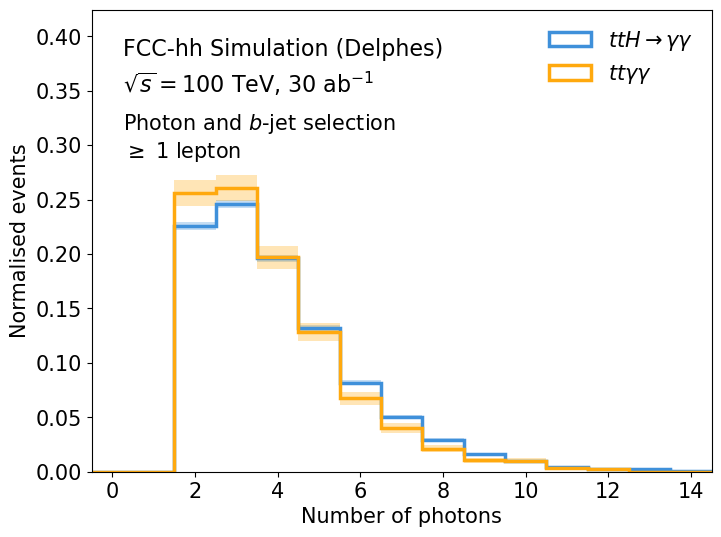

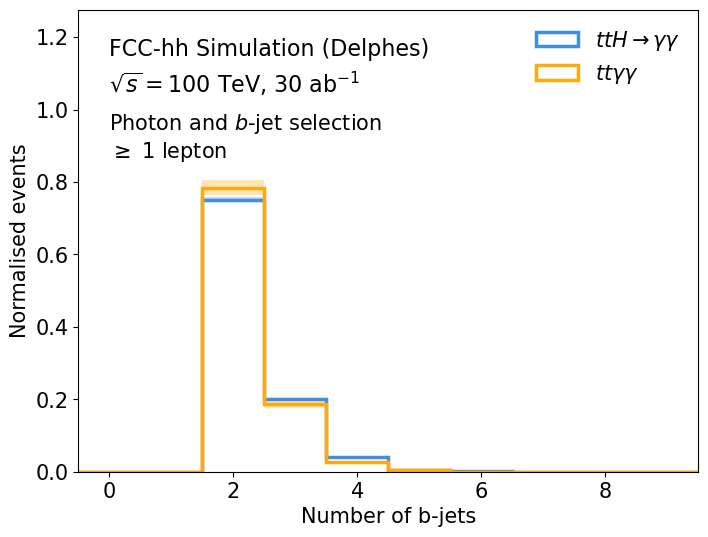

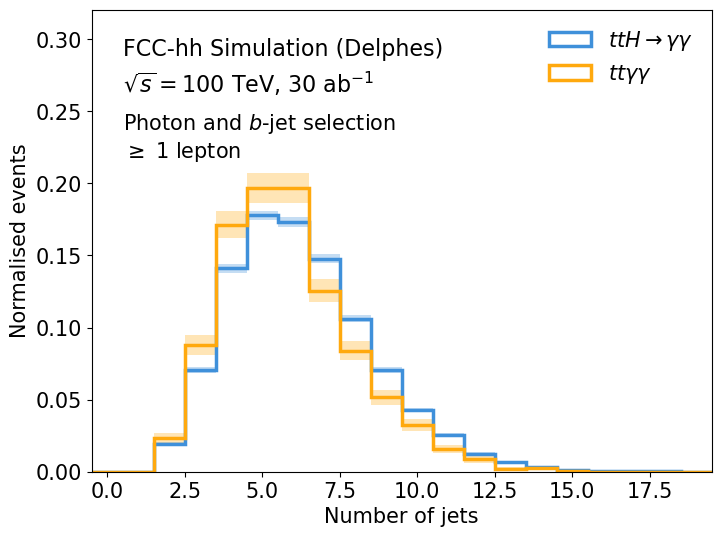

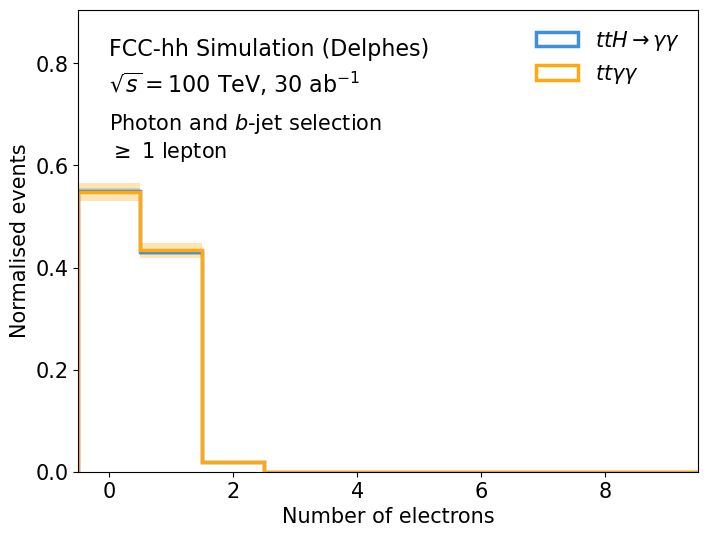

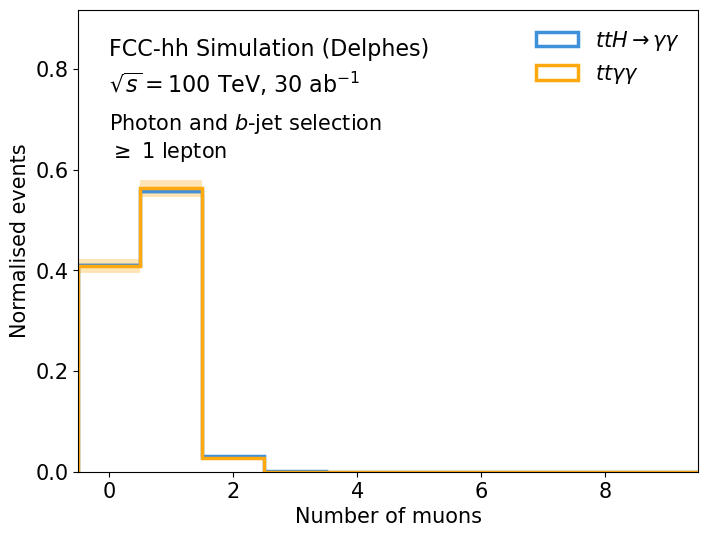

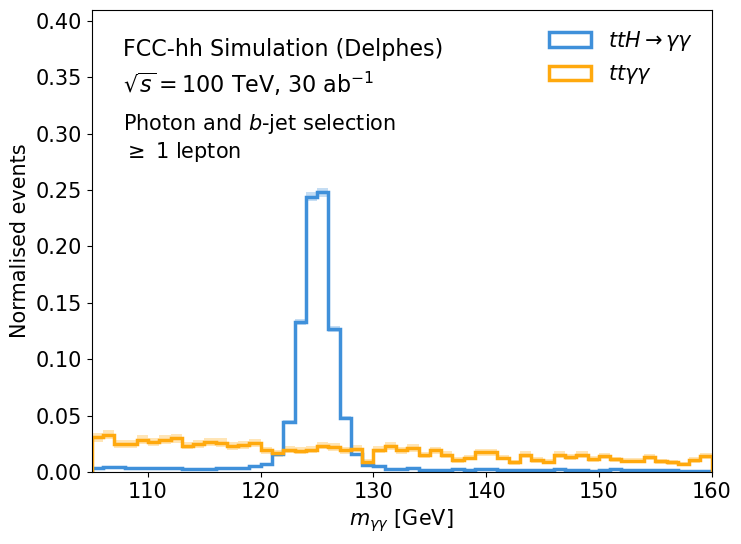

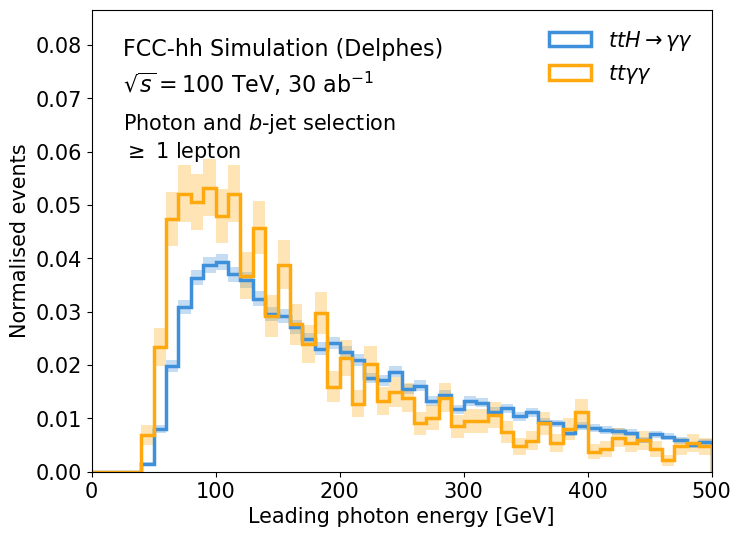

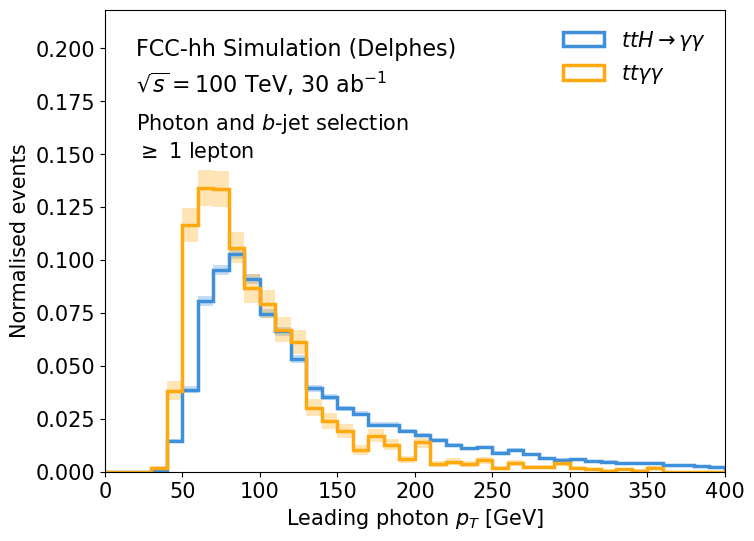

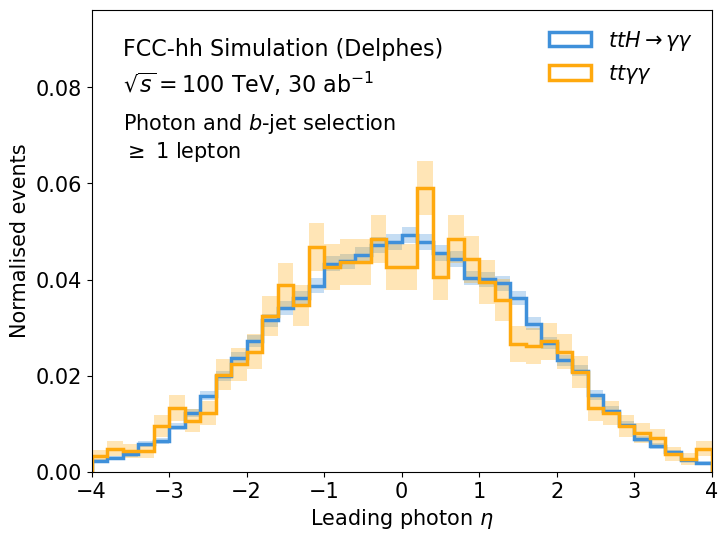

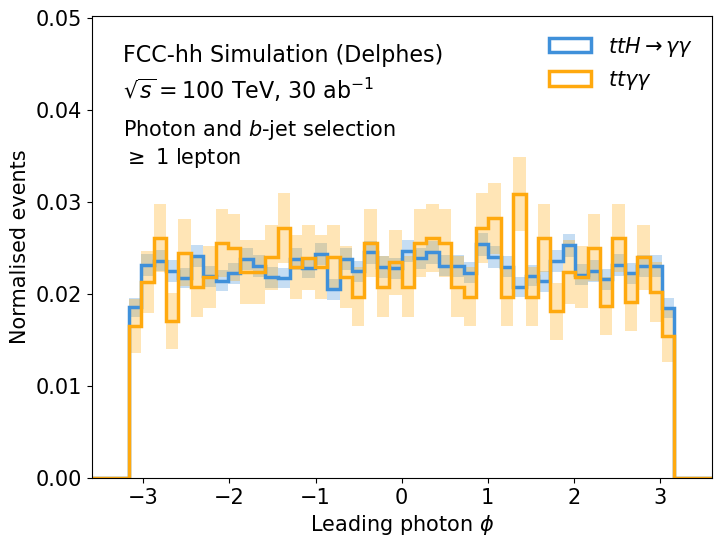

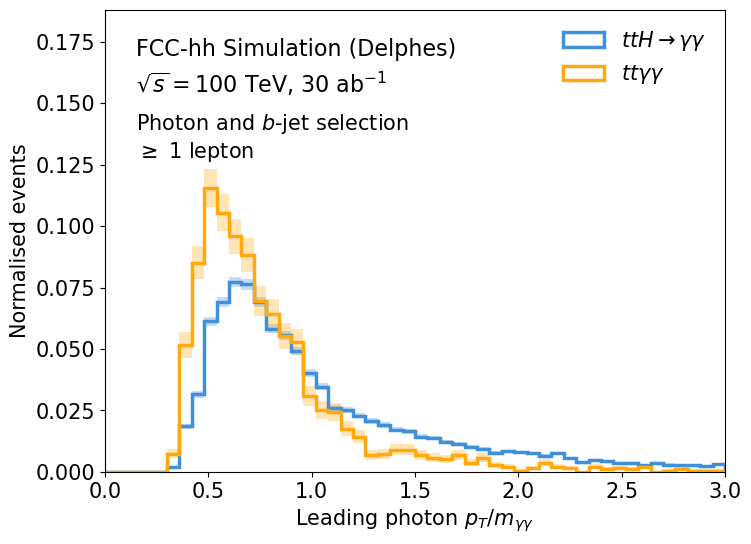

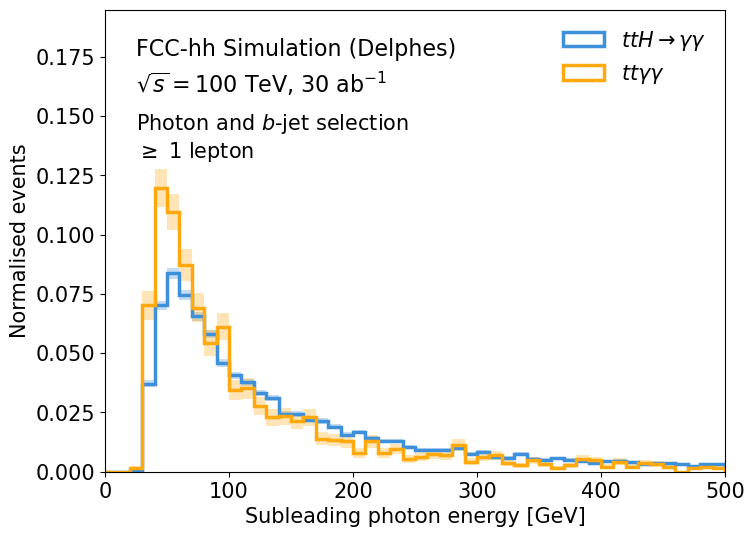

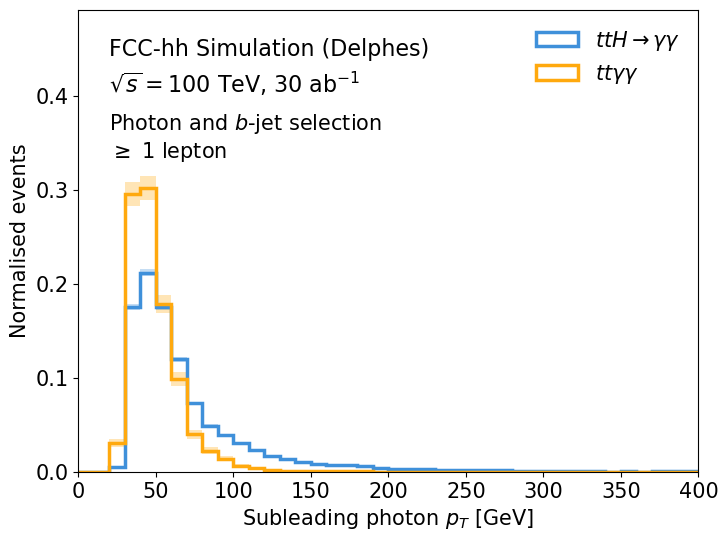

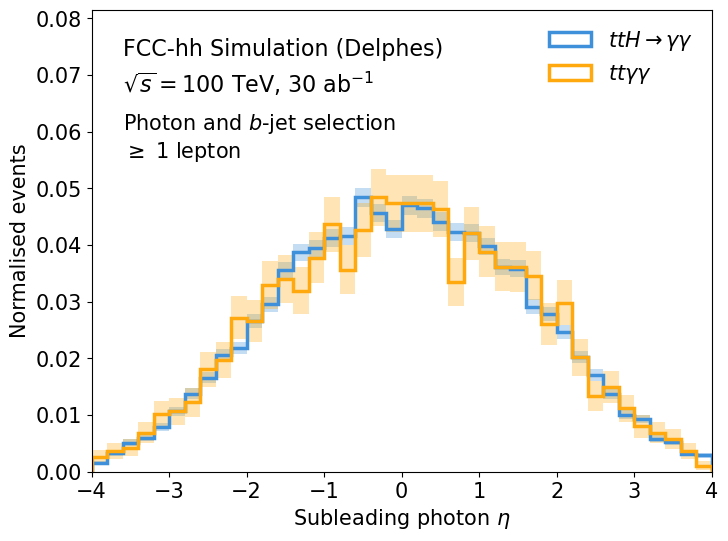

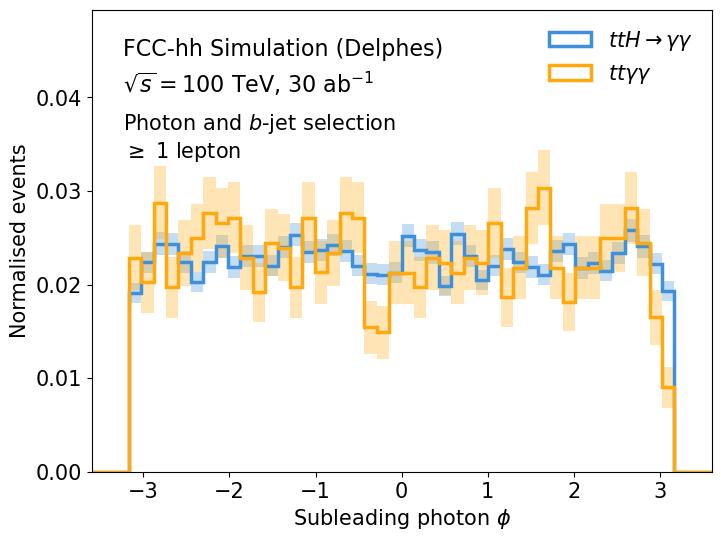

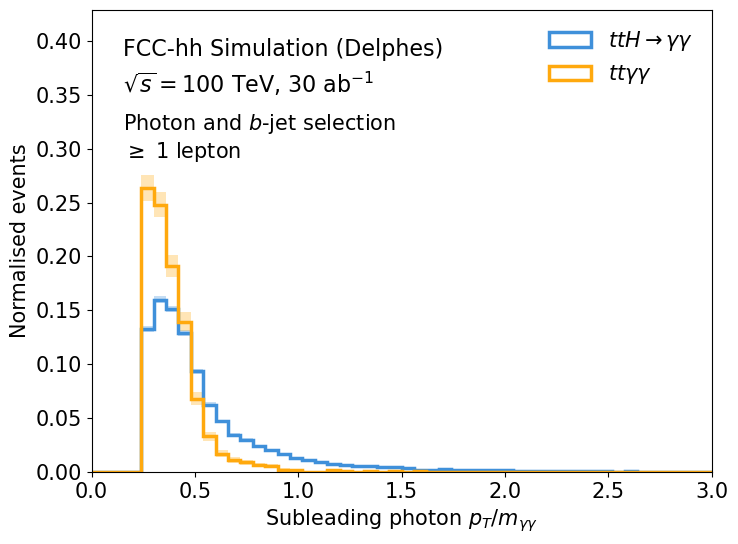

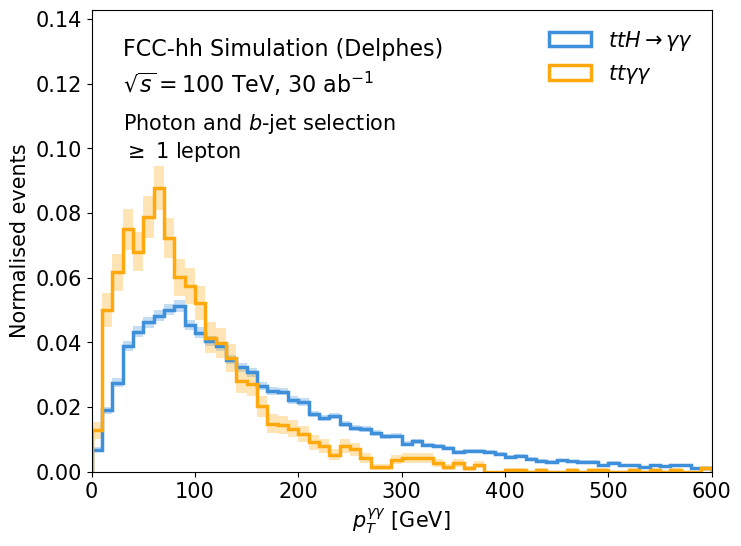

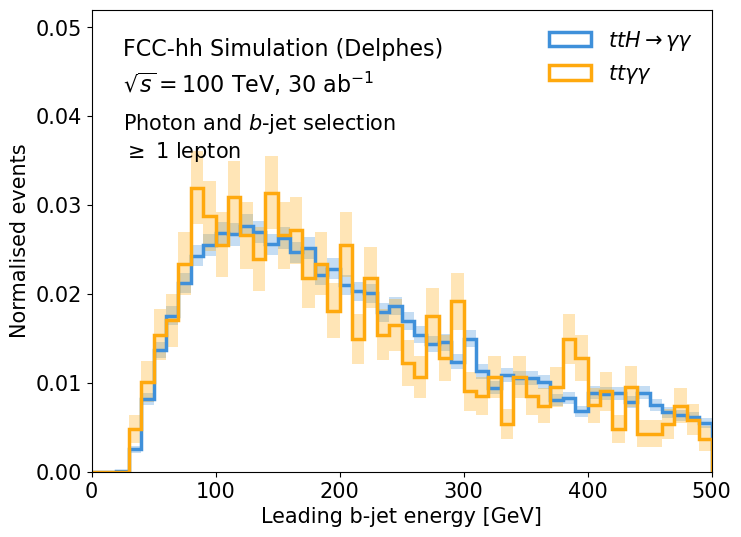

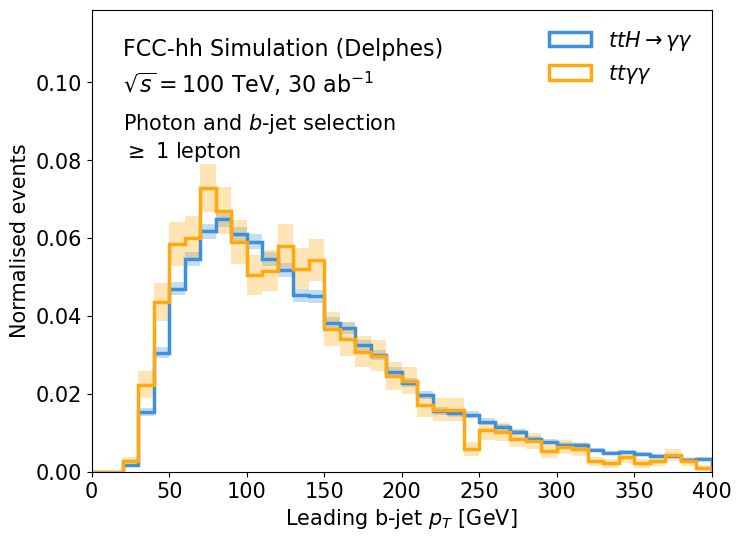

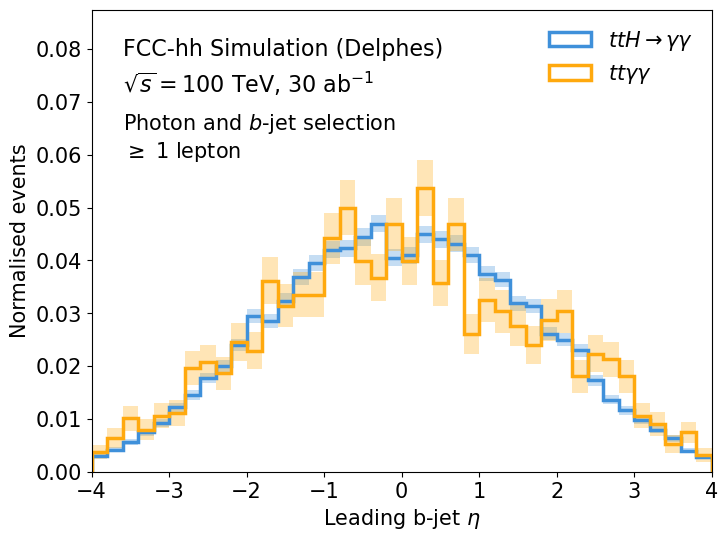

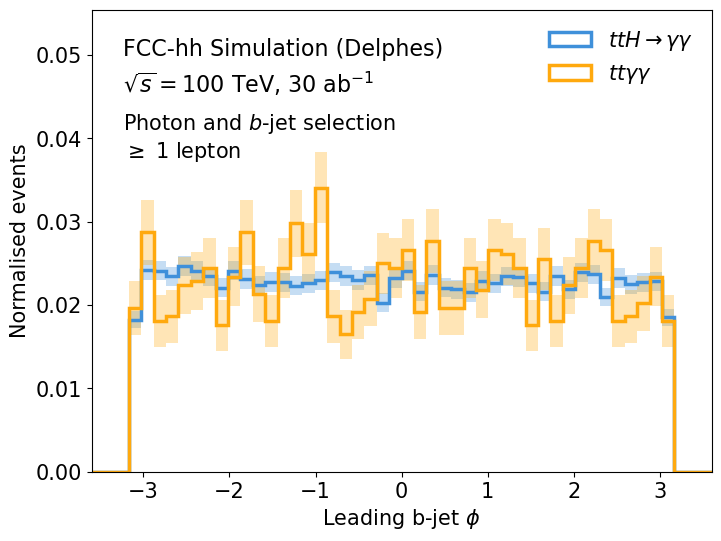

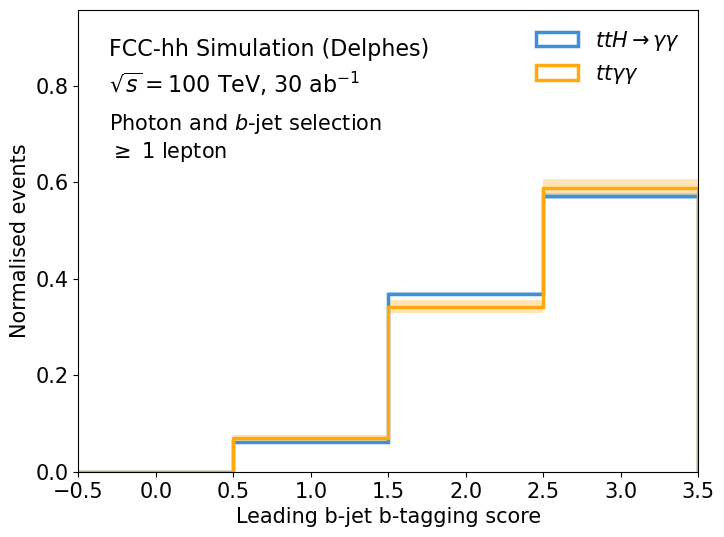

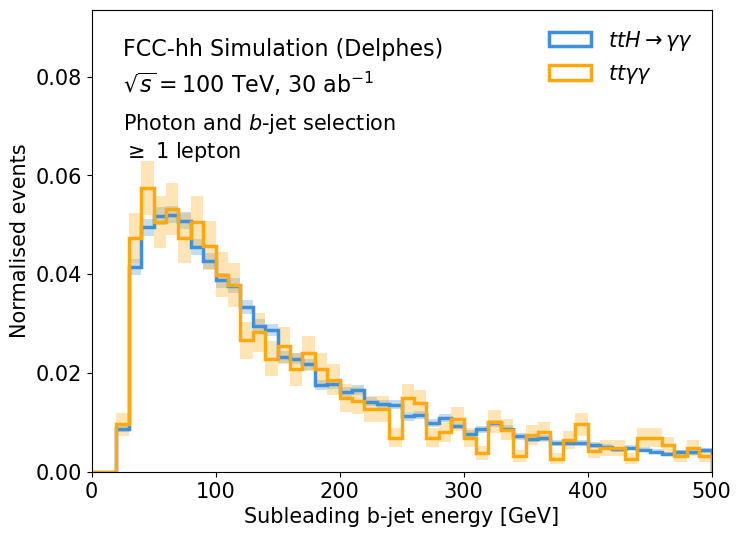

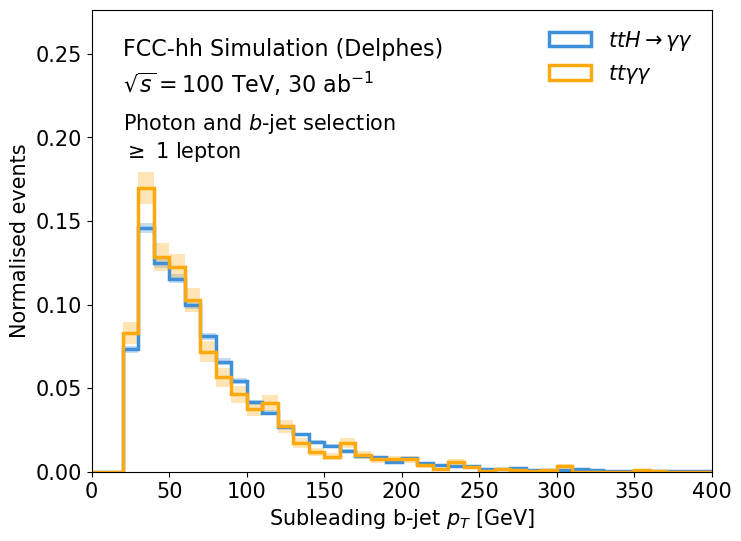

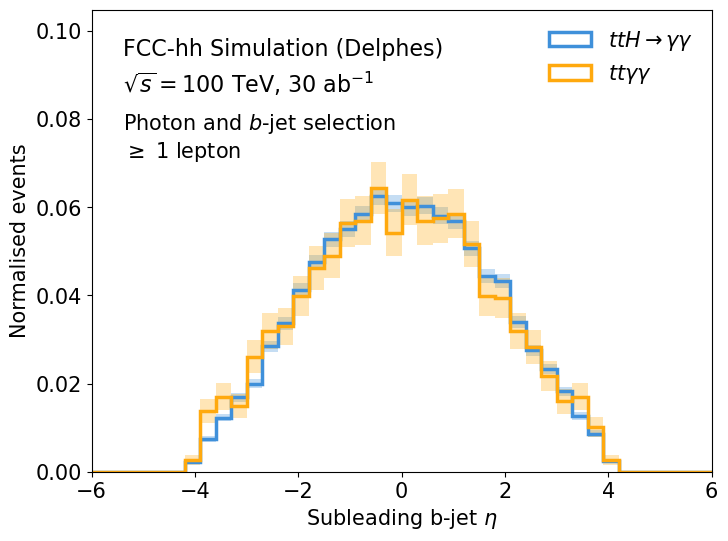

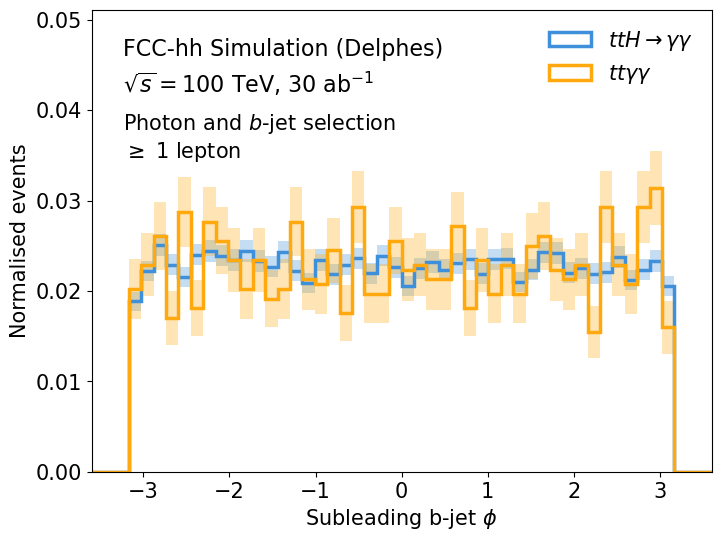

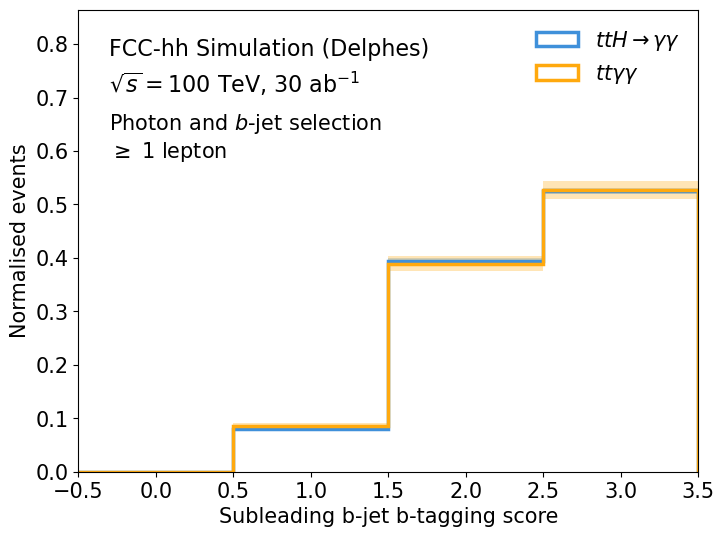

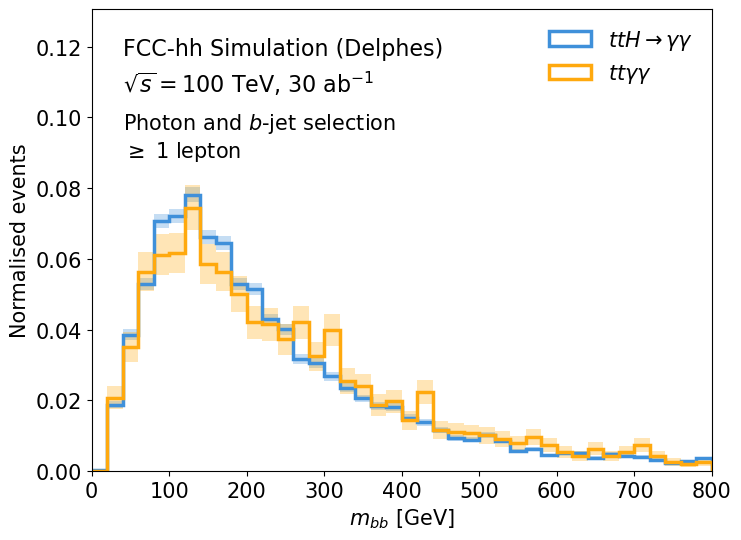

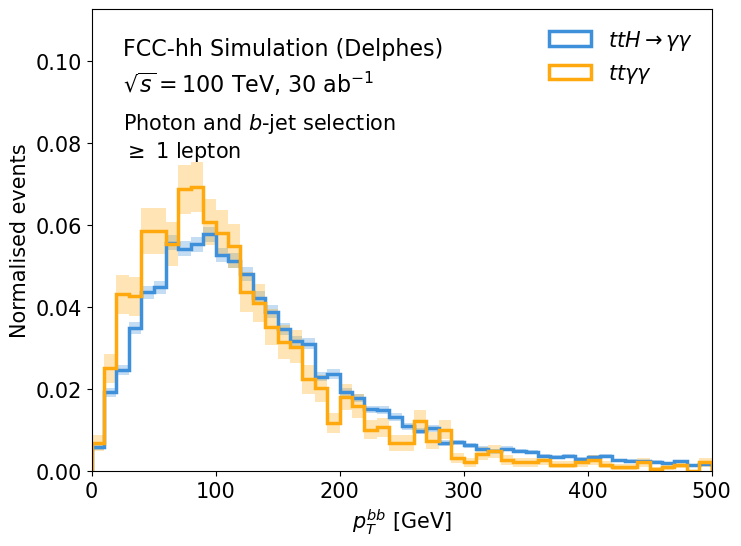

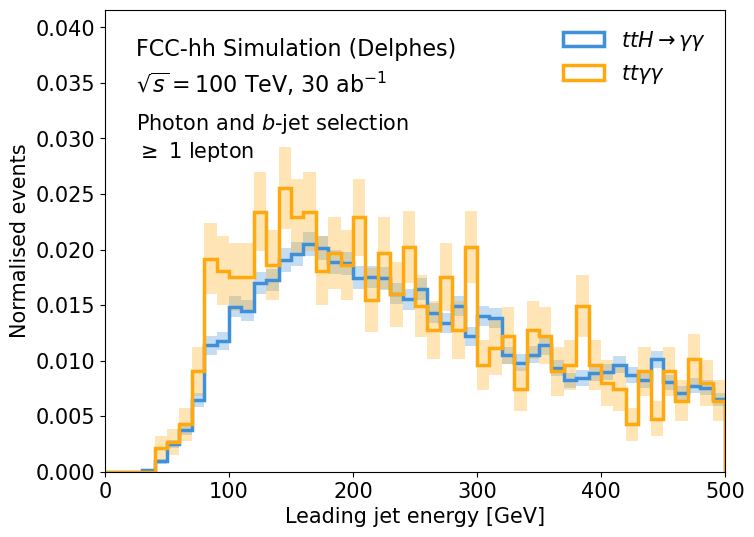

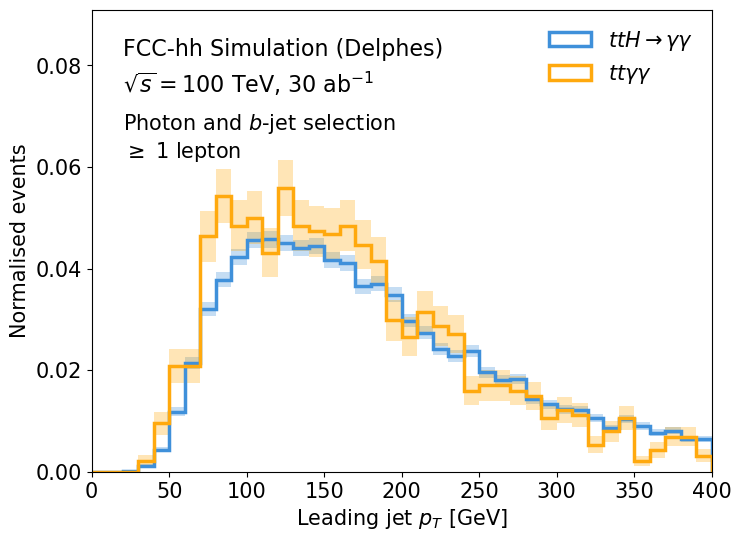

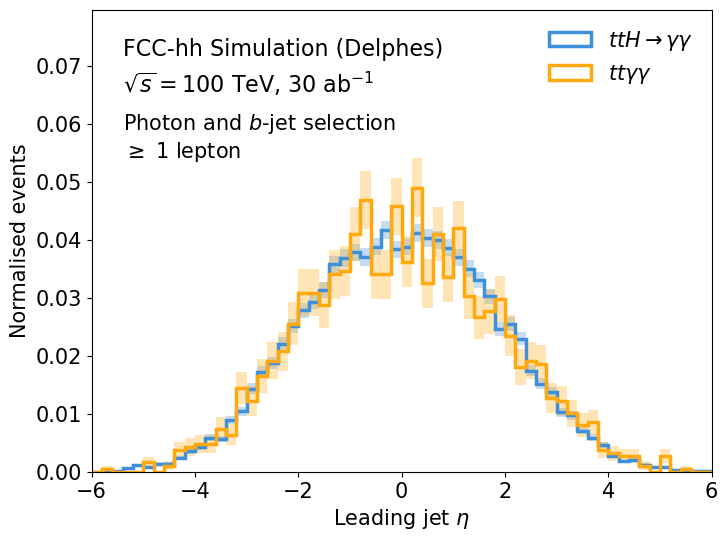

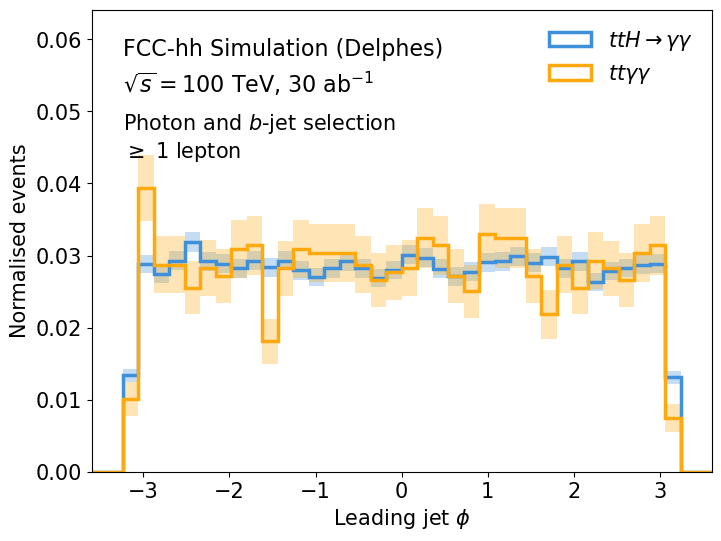

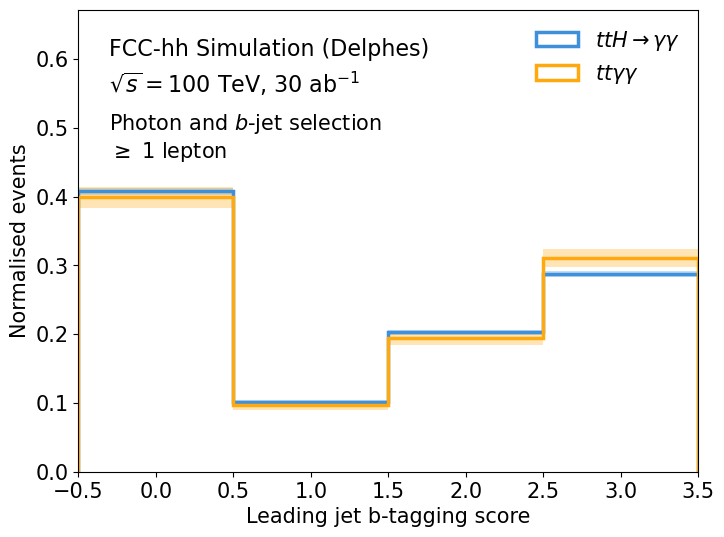

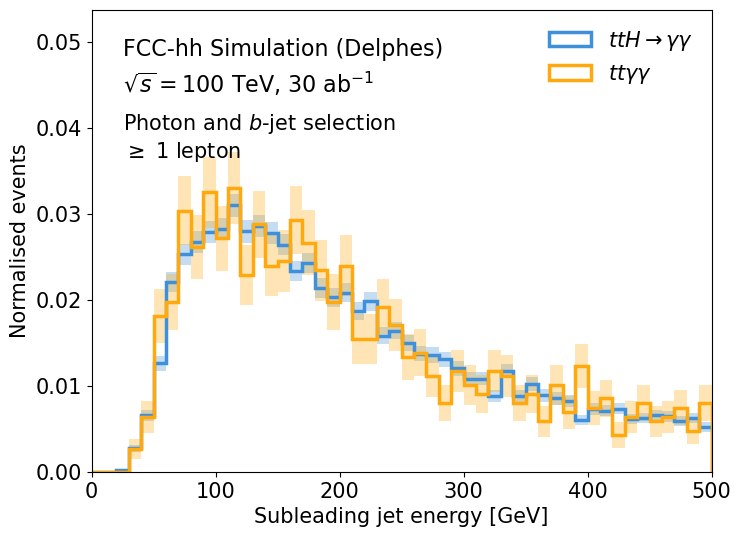

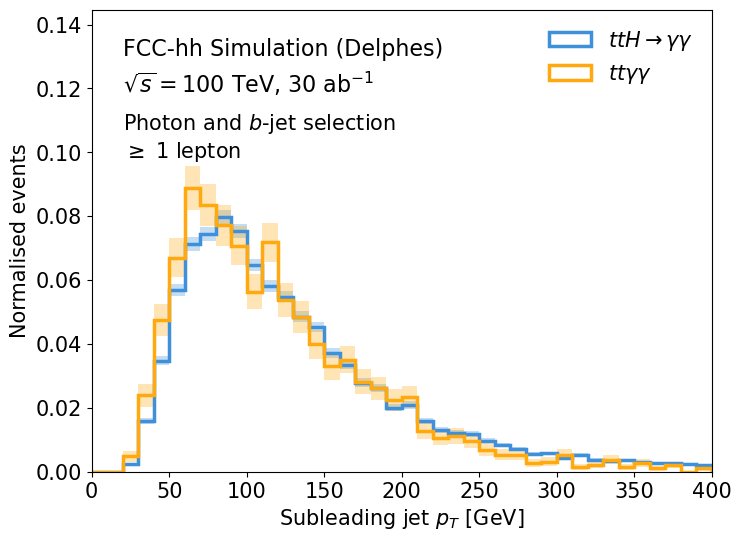

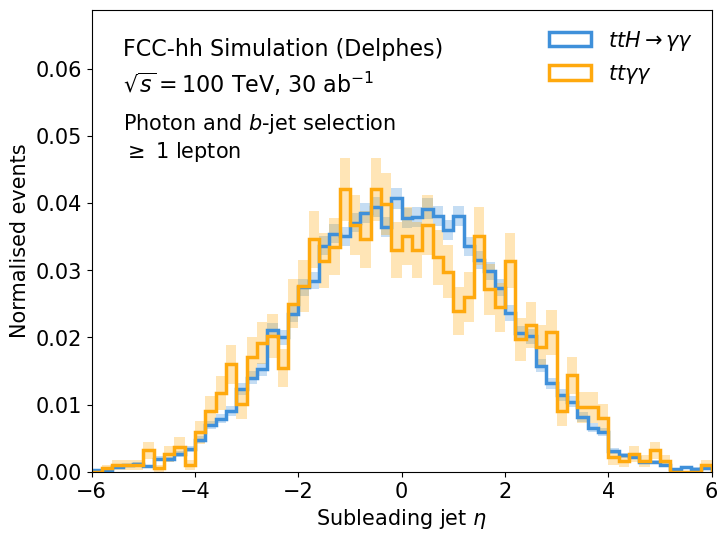

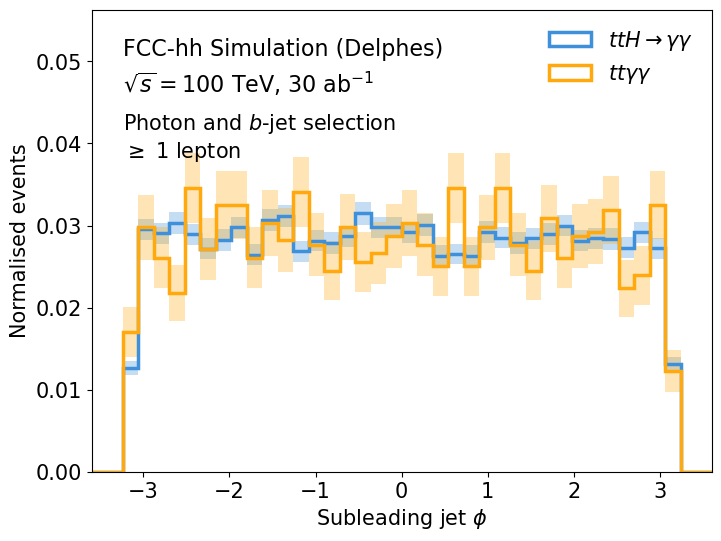

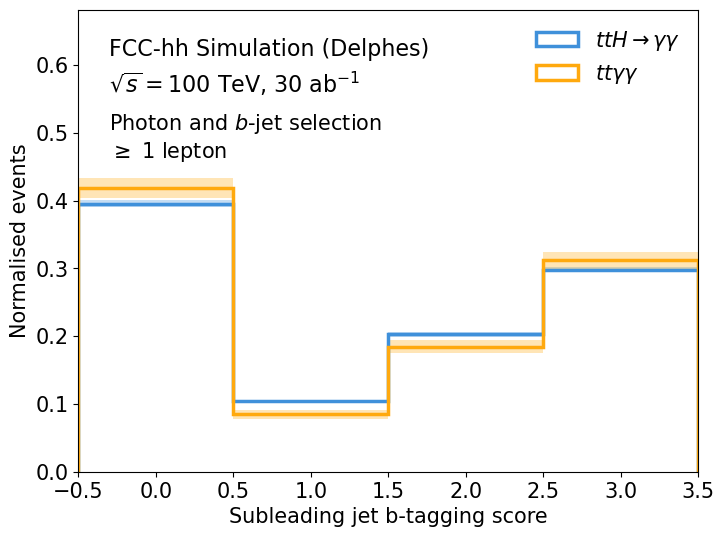

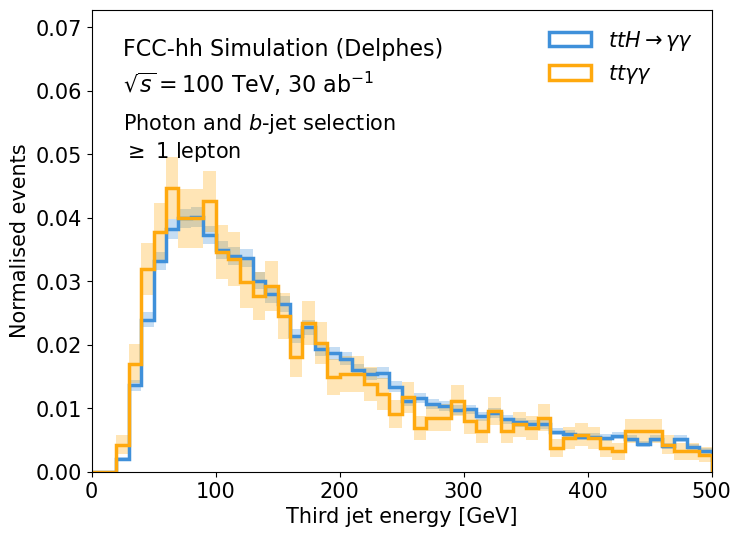

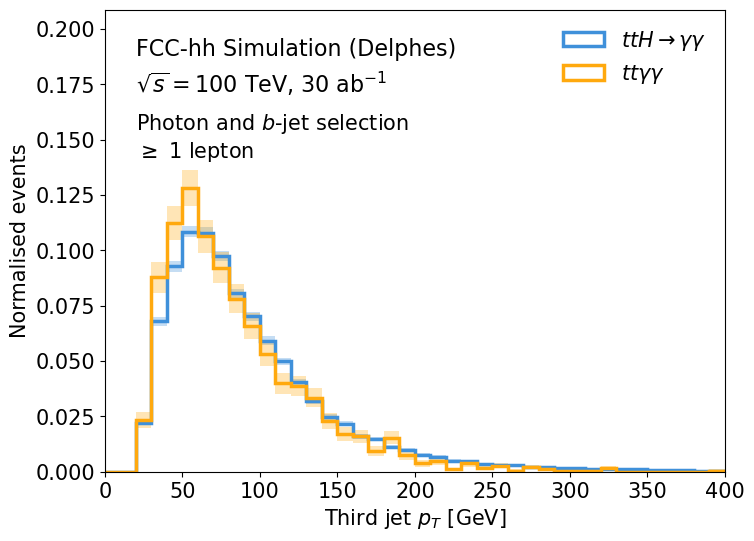

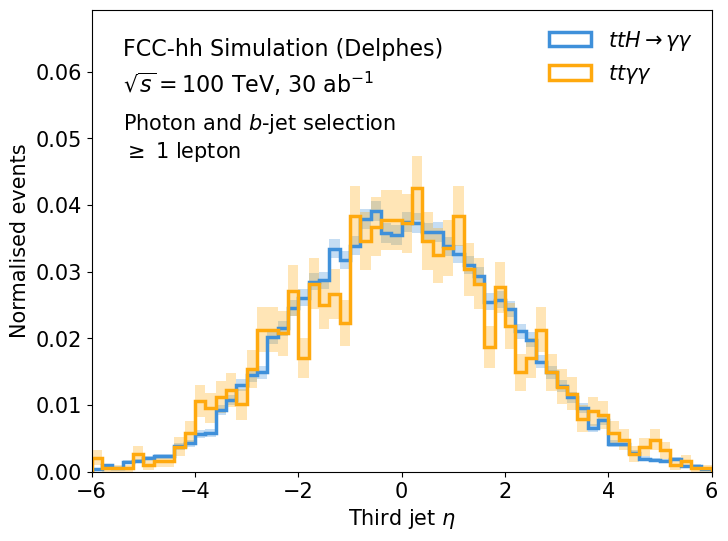

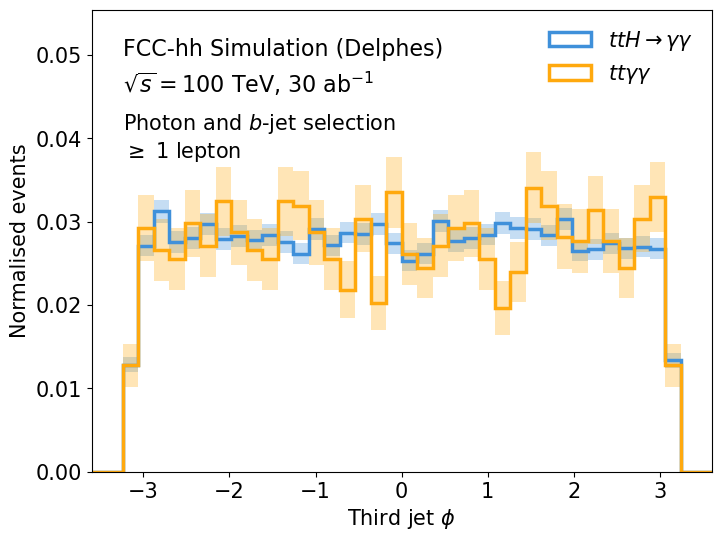

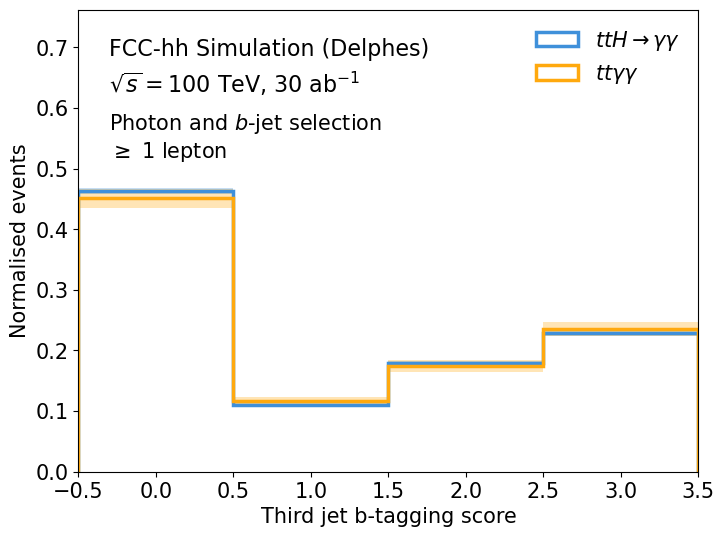

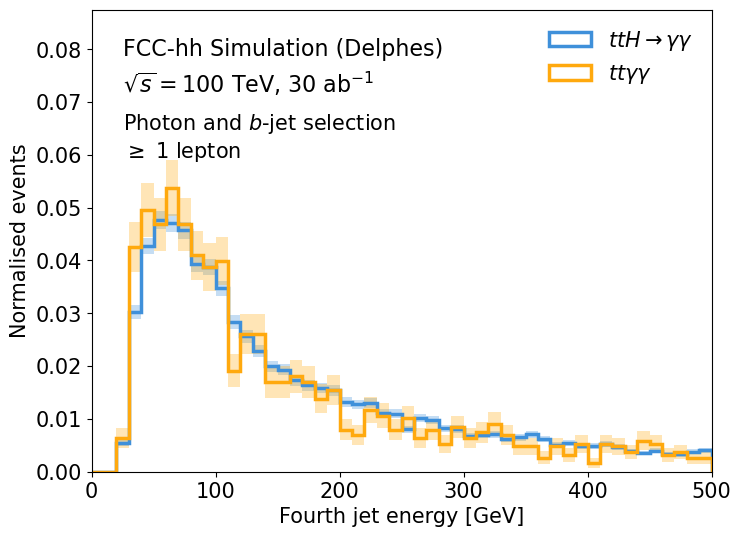

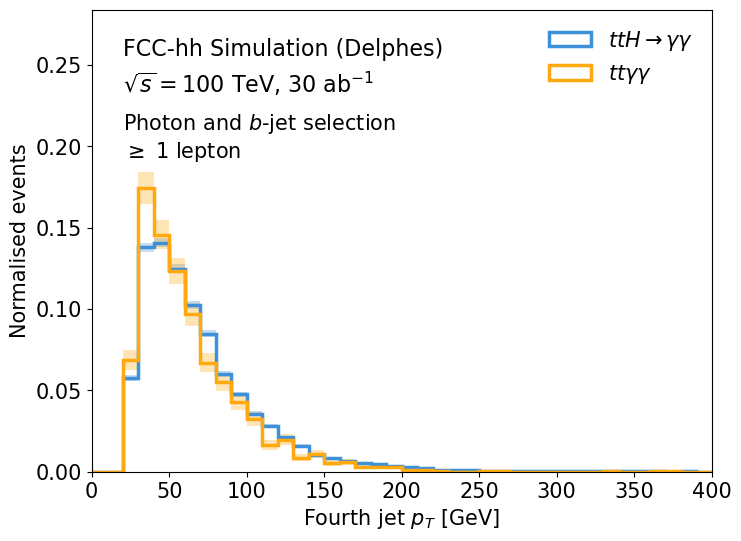

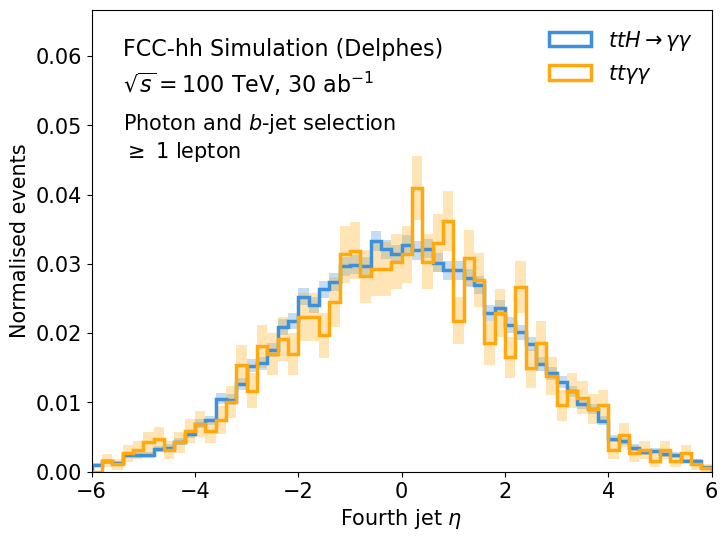

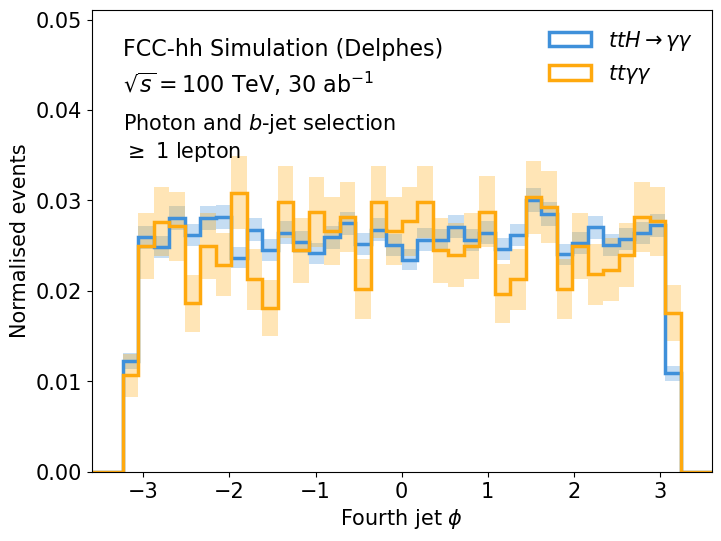

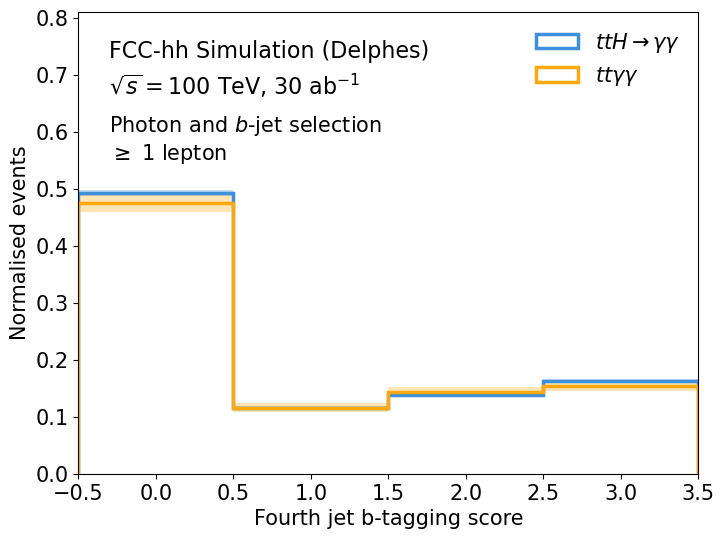

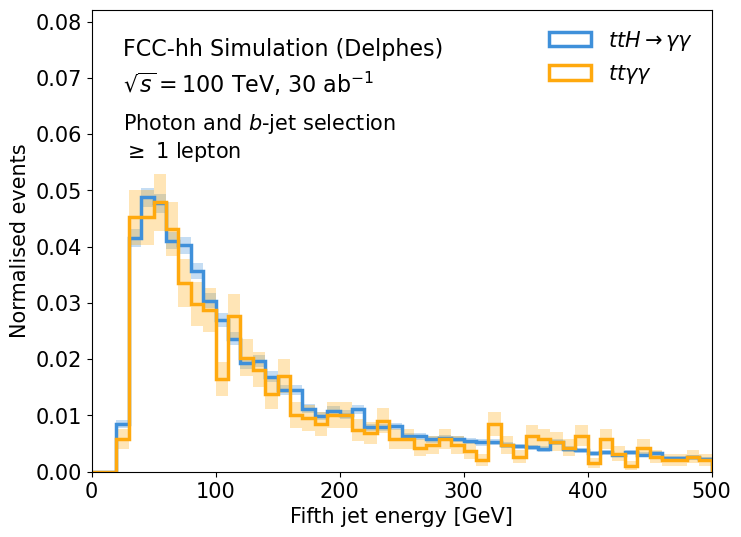

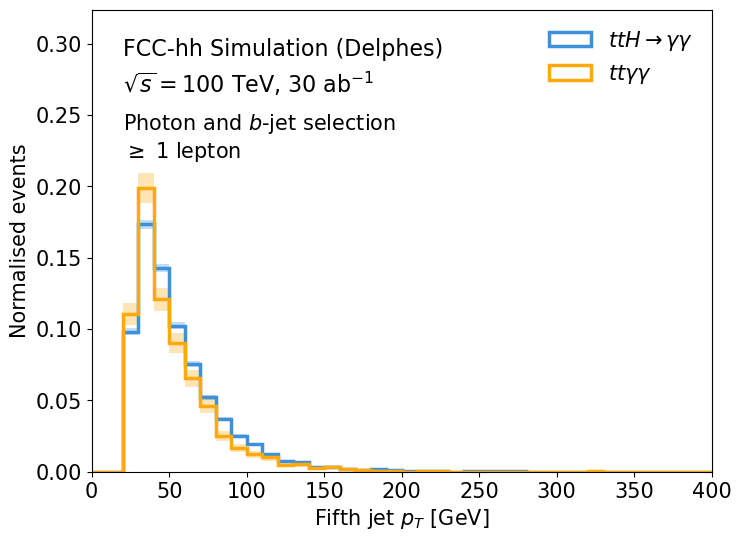

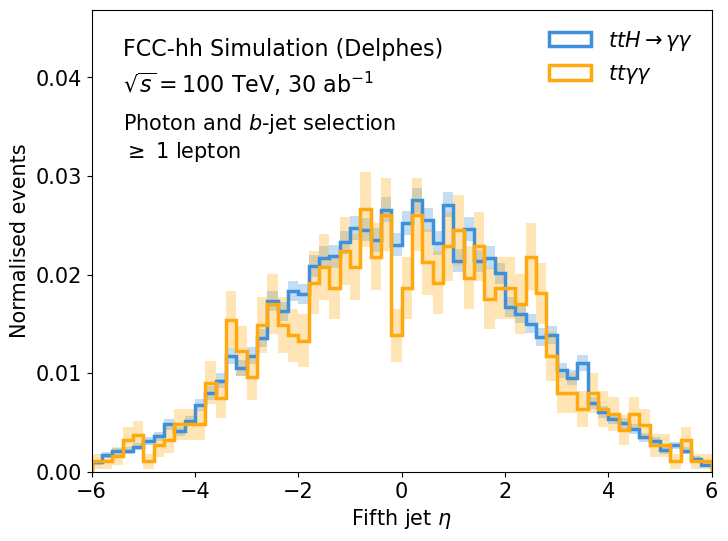

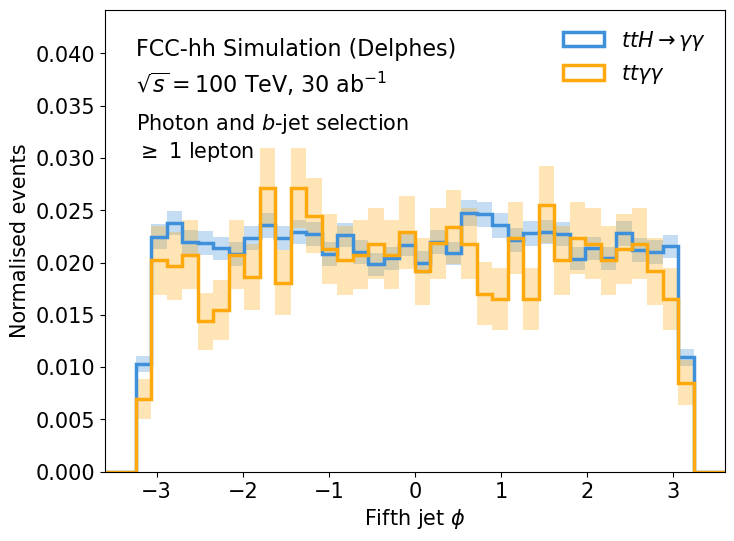

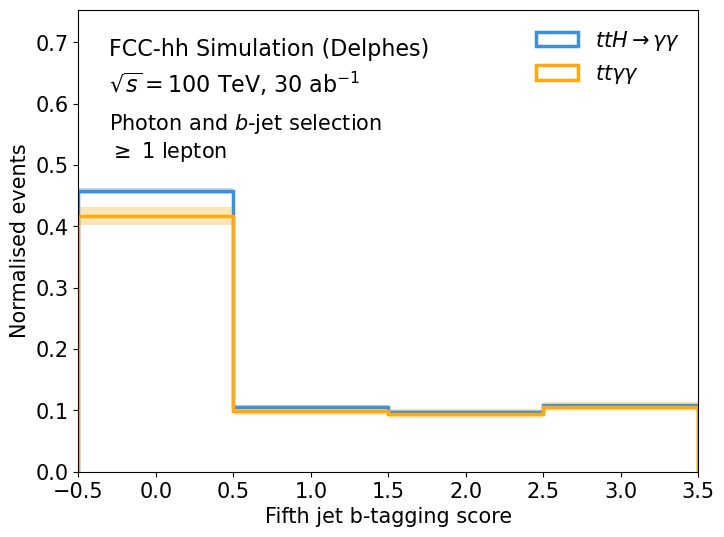

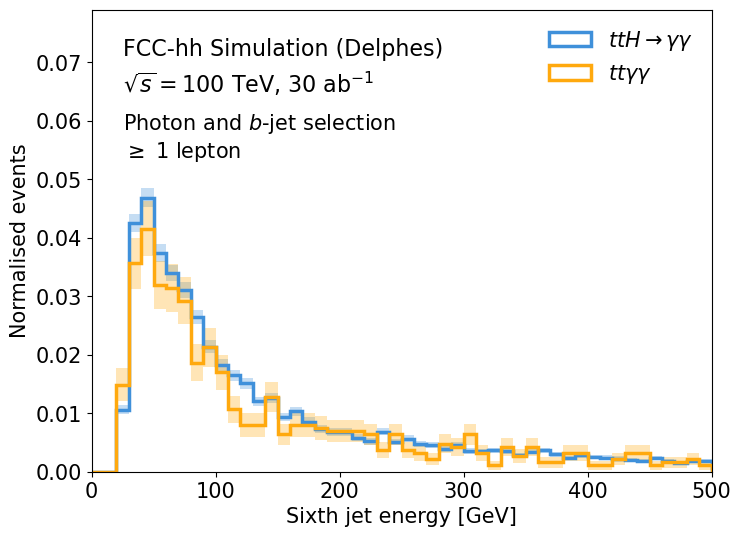

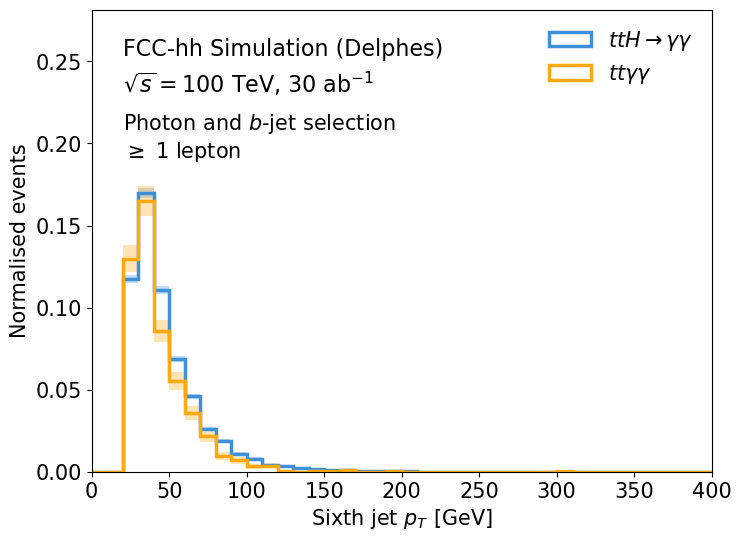

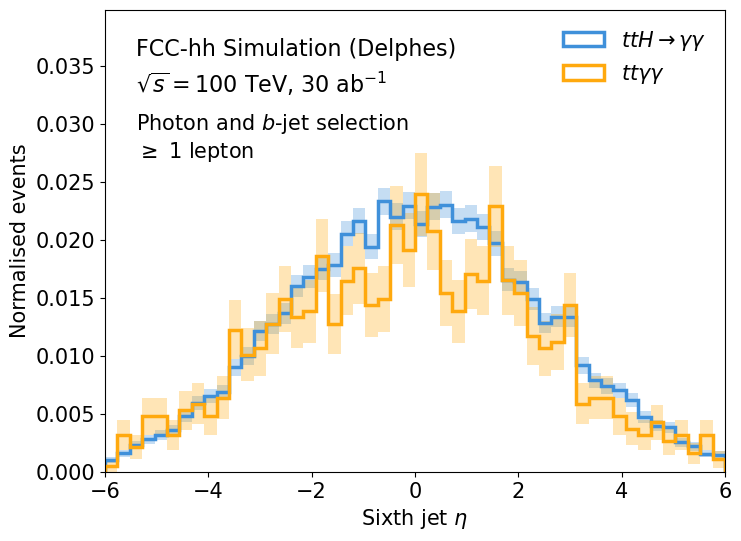

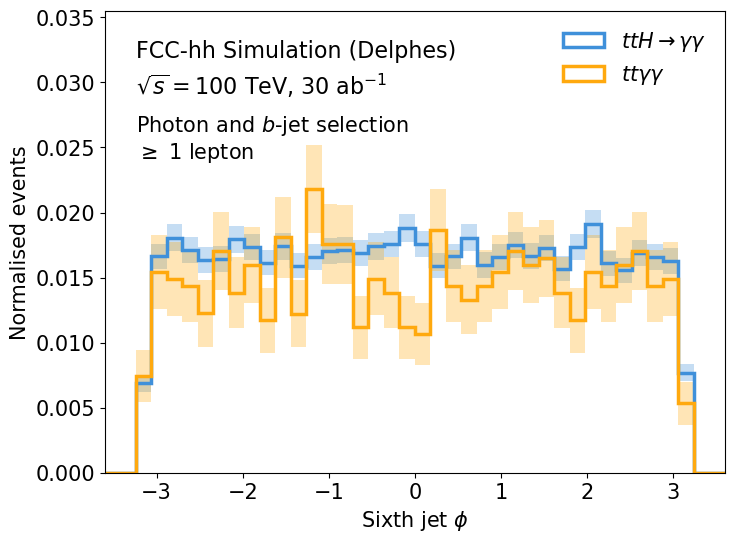

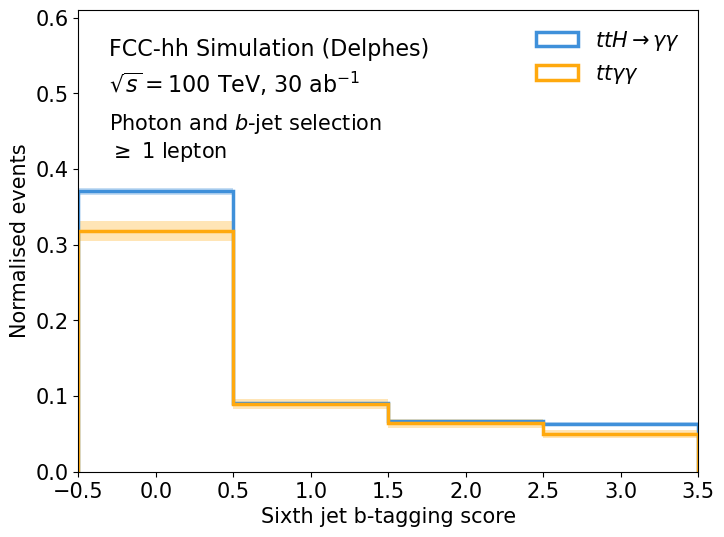

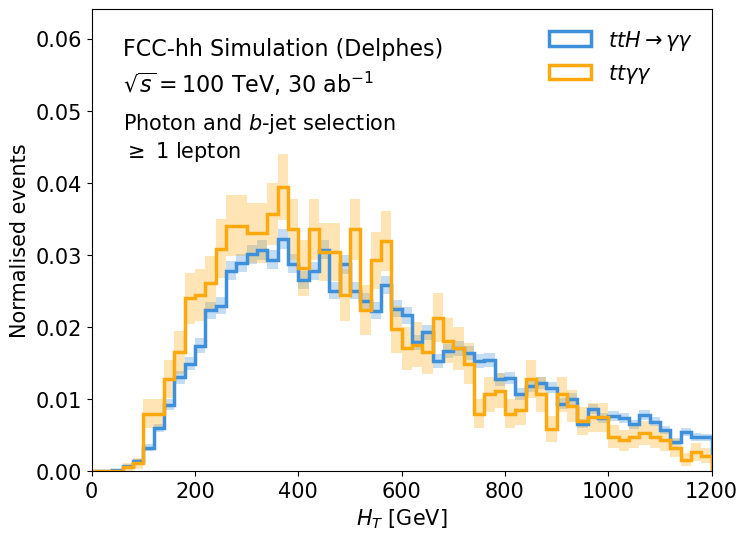

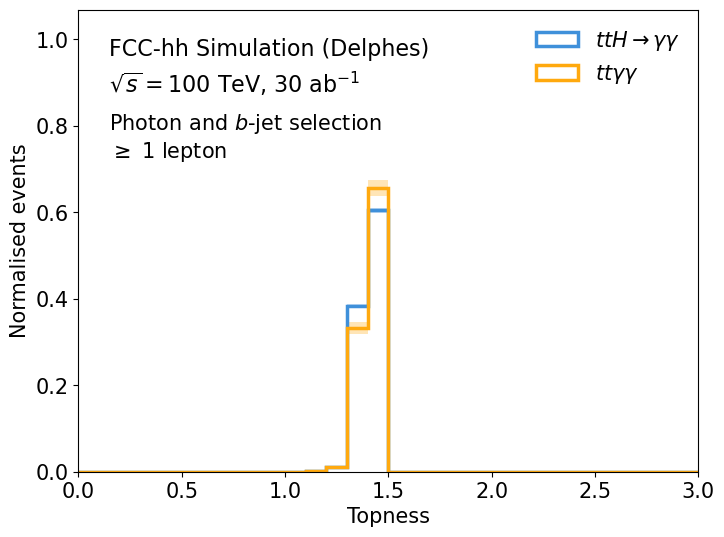

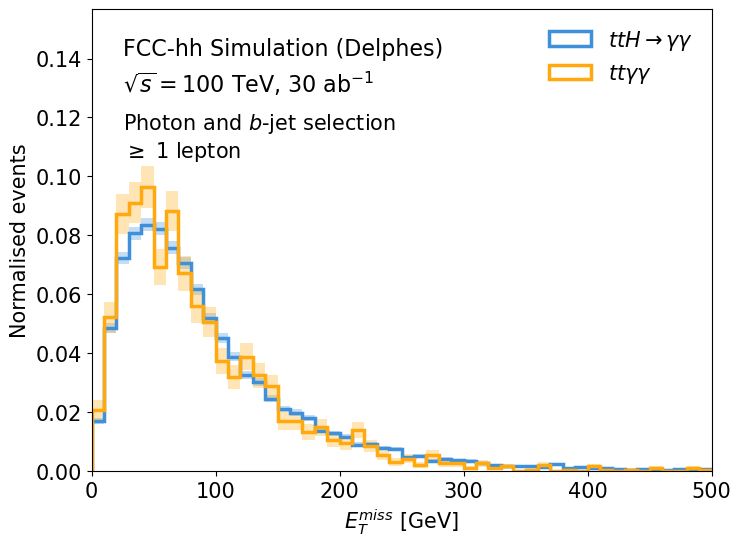

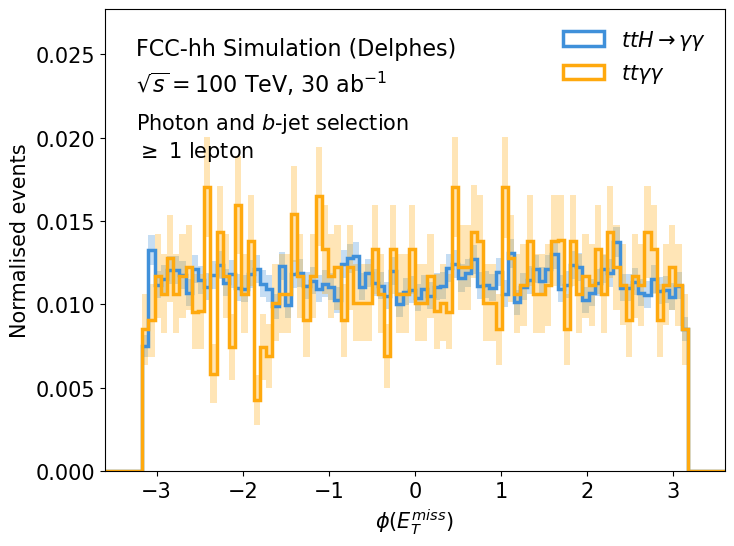

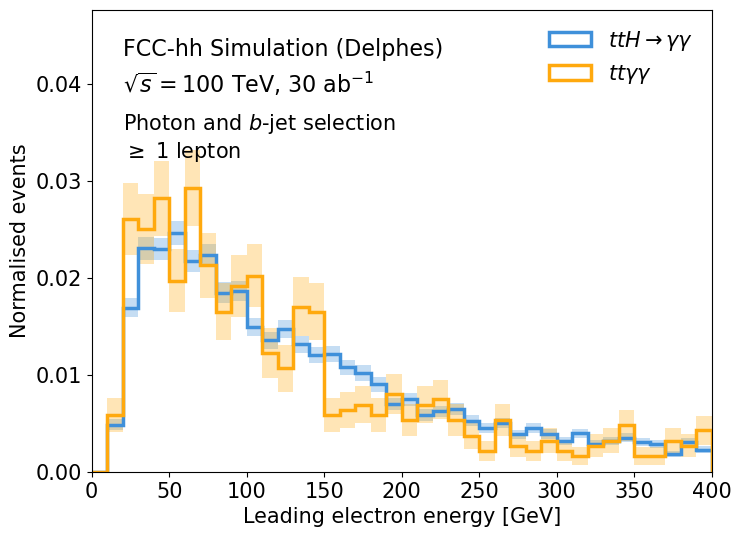

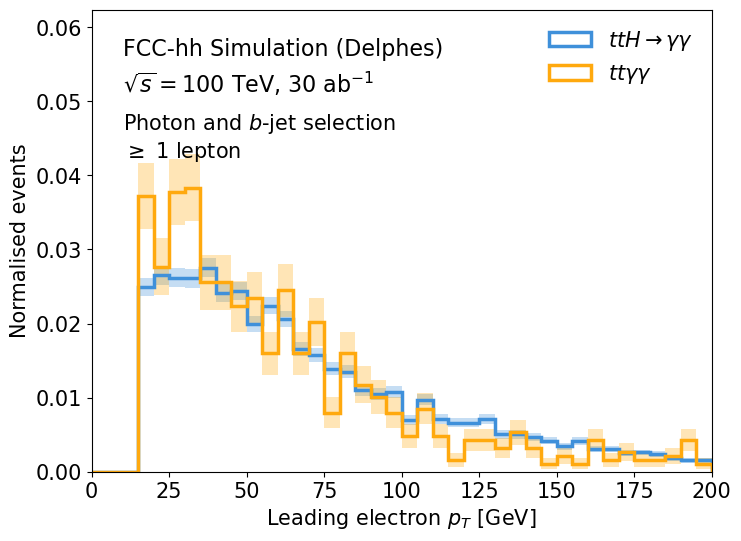

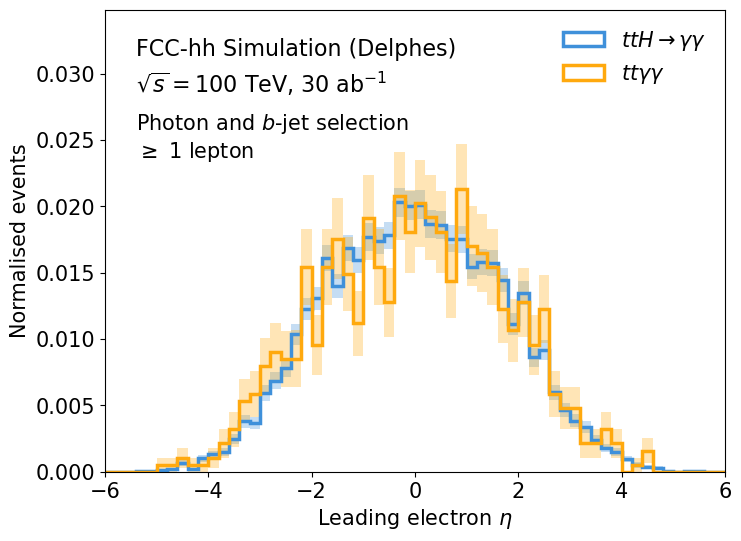

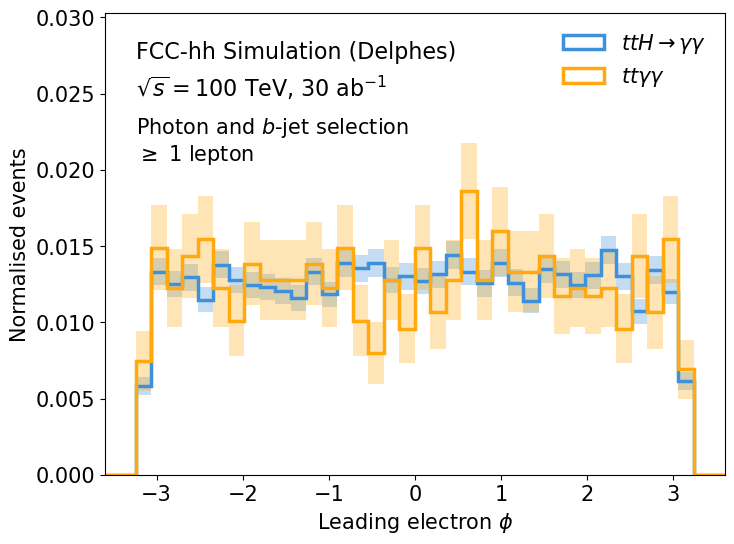

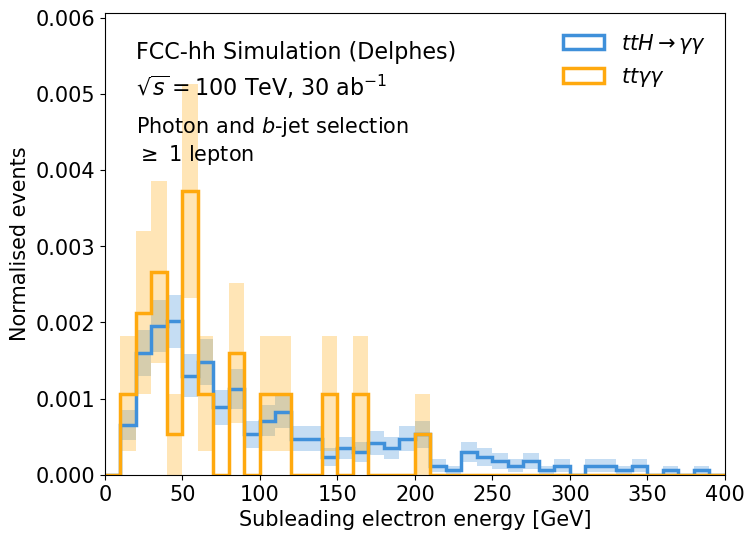

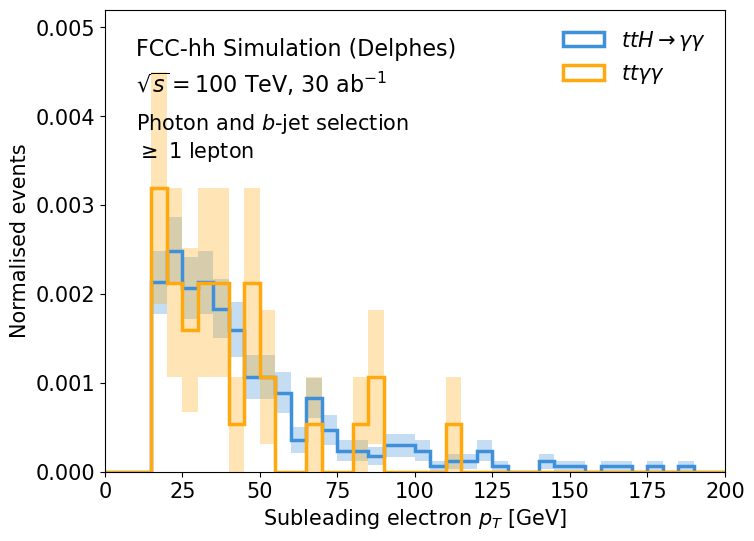

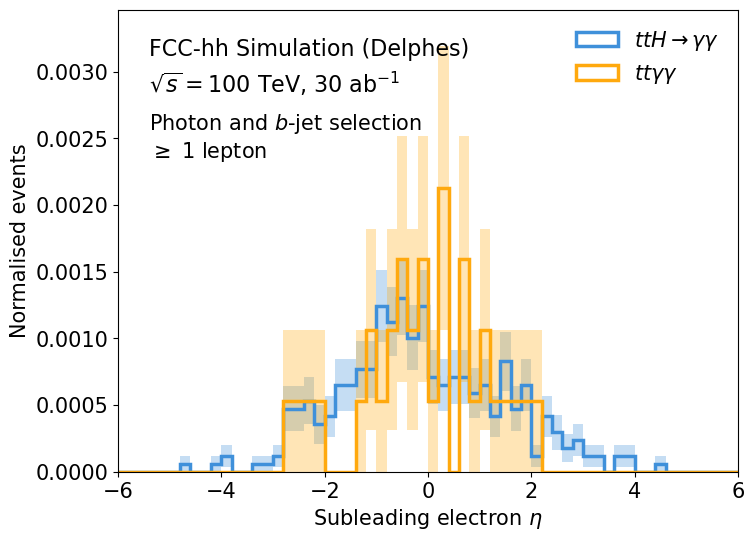

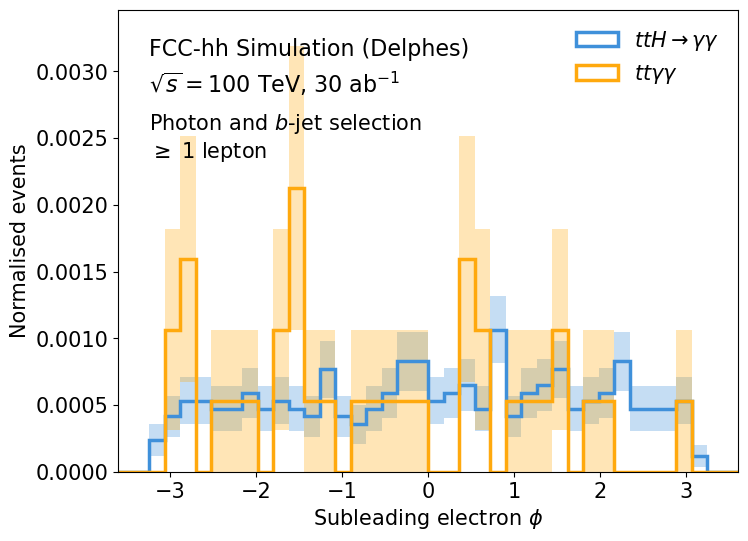

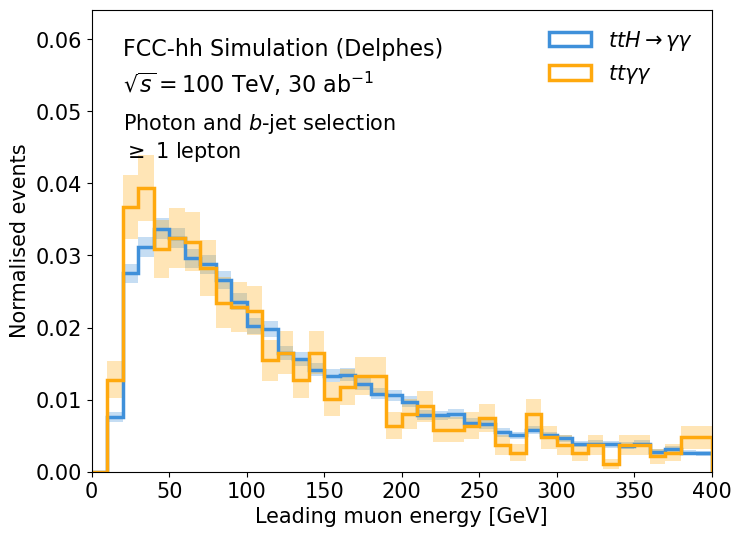

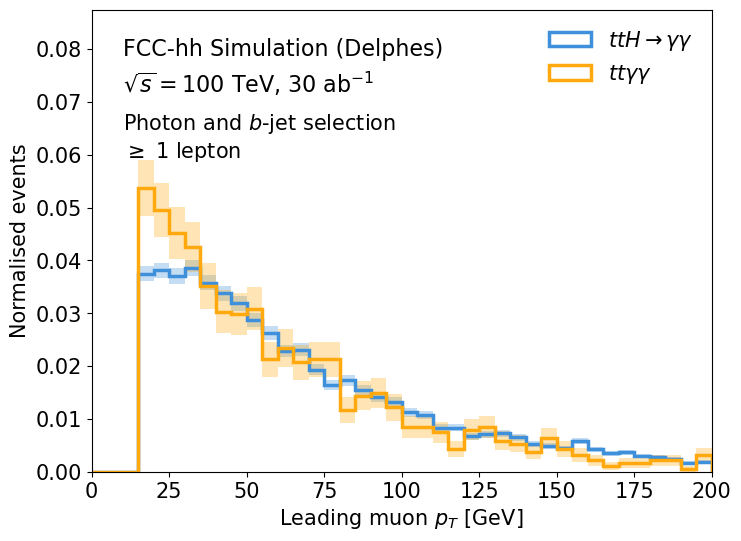

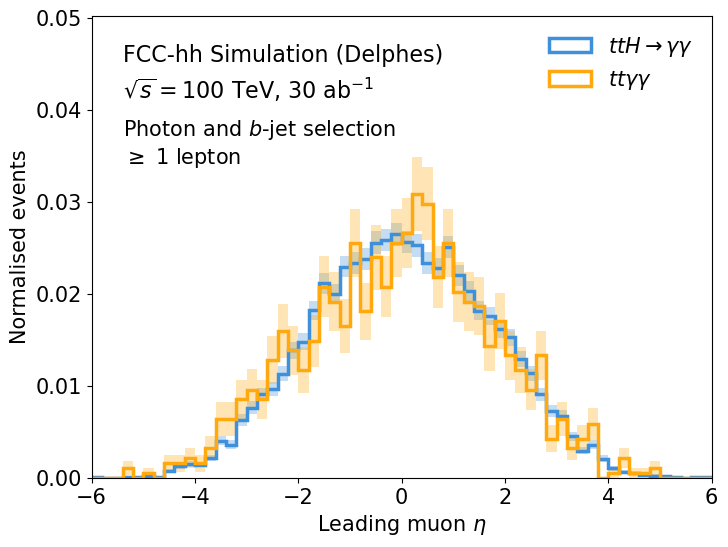

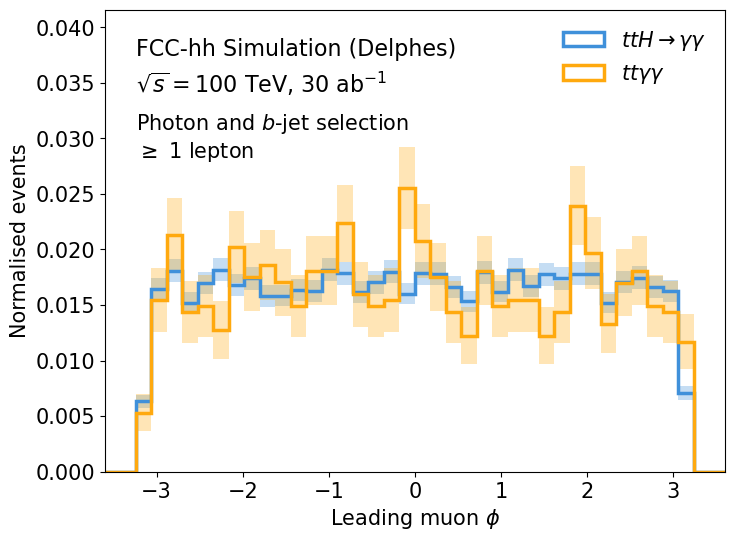

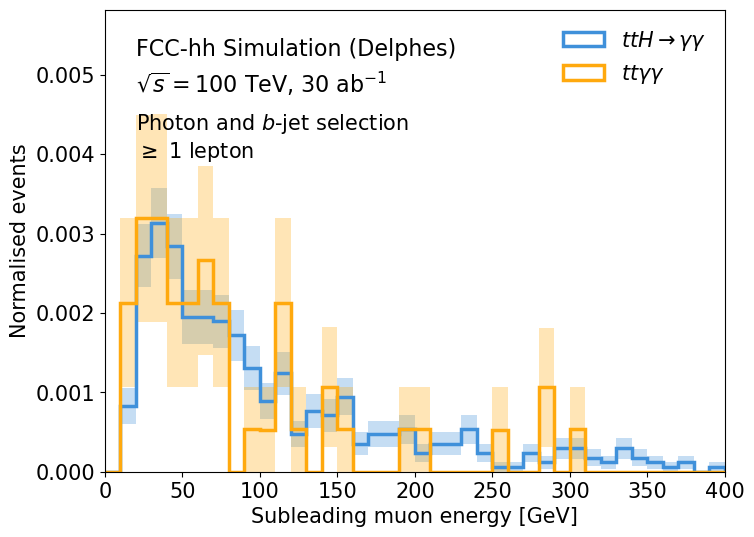

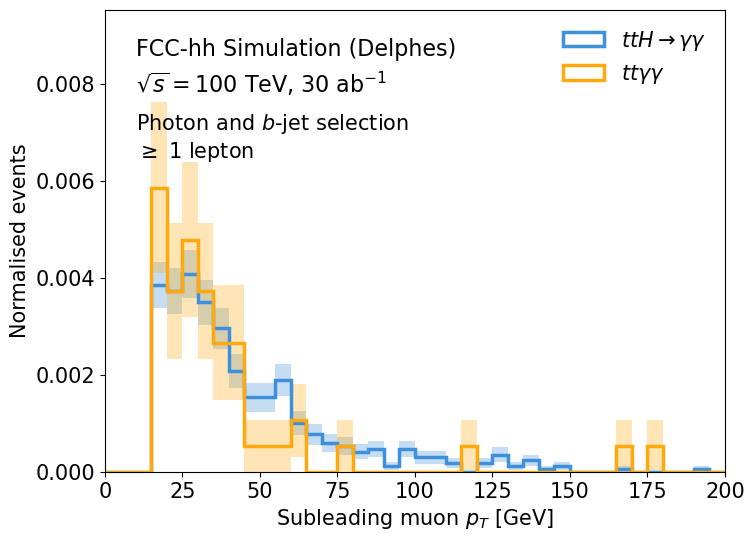

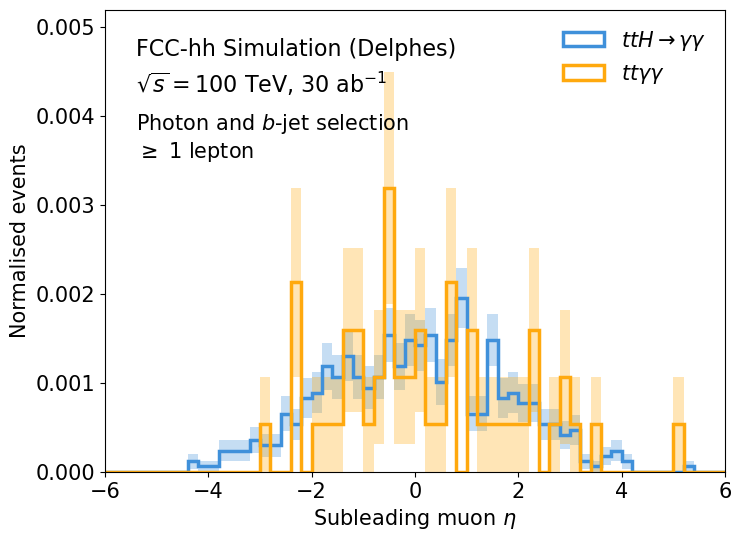

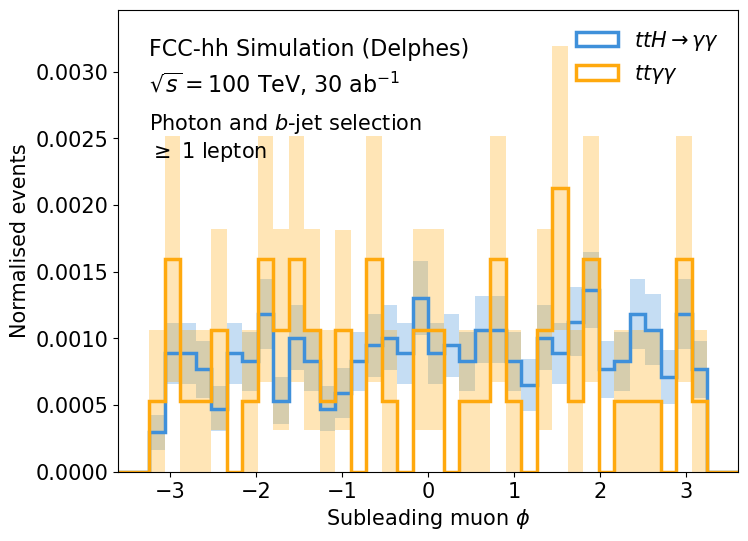

In [11]:
# now plot all of the variables
i = 0
for variable, infos in variables_dict.items() :
    fig, ax = plt.subplots(
        nrows=1,
        ncols=1,
        figsize=(8,6)
    )
    for p in process.keys() :
        bin_values, bin_edges, _ = ax.hist(df[p][sel_key][variable], 
                                           weights=df[p][sel_key]["weight"]/df[p][sel_key]["weight"].sum(),
                                           bins=infos["bin"], range=(infos["xmin"], infos["xmax"]),
                                           histtype='step', linewidth=2.5, color=process[p]["color"],
                                           label=process[p]["label"])
        x = 0.5*(bin_edges[1:]+bin_edges[:-1])
        xerr = 0.5*(bin_edges[1:]-bin_edges[:-1])
        bin_unc, _ = np.histogram(df[p][sel_key][variable], 
                                  weights=(df[p][sel_key]["weight"]/df[p][sel_key]["weight"].sum())**2,
                                  bins=infos["bin"], range=(infos["xmin"], infos["xmax"]))
        bin_unc = np.sqrt(bin_unc)
        error_boxes(ax, x, bin_values, xerr, bin_unc, alpha=0.3, fc=process[p]["color"])
        
    ax.text(0.05, 0.90, r"FCC-hh Simulation (Delphes)", transform=ax.transAxes, fontsize=16)
    ax.text(0.05, 0.82, r"$\sqrt{s}=100$ TeV, 30 ab$^{-1}$", transform=ax.transAxes, fontsize=16)
    ax.text(0.05, 0.68, sel_label, transform=ax.transAxes, fontsize=15)

    ax.legend(loc='upper right', frameon=False, fontsize=15)
    xlabel = infos["latex"] if "latex" in list(infos.keys()) else infos["title"]
    ax.set_xlabel(xlabel)
    ax.set_ylabel(r'Normalised events')

    ax.set_xlim(infos["xmin"], infos["xmax"])
    ymin,ymax = ax.get_ylim() 
    ax.set_ylim(ymin, ymax+np.abs((ymax-ymin))*0.55)

    plotname = infos["name"]+"_ttHyy_analysis_"+sel_key
    plt.savefig(os.path.join(outdir, plotname+".pdf"), bbox_inches='tight')
    plt.savefig(os.path.join(outdir, plotname+".png"), bbox_inches='tight')
    plt.show()

In [12]:
import pyhf

ModuleNotFoundError: No module named 'pyhf'